In [1]:
import os
import sys
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob

BASE_DIR = "/home/aninotna/magister/tesis/justh2_pipeline"
DATA_DIR = os.path.join(BASE_DIR, "data")
PLOTS_DIR = os.path.join(BASE_DIR, "plots", "cluster_characterization")
os.makedirs(PLOTS_DIR, exist_ok=True)

print("Entorno configurado")
print(f"  BASE_DIR: {BASE_DIR}")
print(f"  DATA_DIR: {DATA_DIR}")
print(f"  PLOTS_DIR: {PLOTS_DIR}")

Entorno configurado
  BASE_DIR: /home/aninotna/magister/tesis/justh2_pipeline
  DATA_DIR: /home/aninotna/magister/tesis/justh2_pipeline/data
  PLOTS_DIR: /home/aninotna/magister/tesis/justh2_pipeline/plots/cluster_characterization


## Importación de Resultados de Clustering

Cargamos los resultados exportados desde el notebook `07_experiments_1_clustering.ipynb`.

In [2]:
CLUSTERING_DIR = os.path.join(DATA_DIR, "autoencoder_results", "clustering")

clustering_files = sorted(glob(os.path.join(CLUSTERING_DIR, "clustering_results_*.pkl")))

if not clustering_files:
    raise FileNotFoundError(f"No se encontraron archivos de clustering en {CLUSTERING_DIR}")

latest_file = clustering_files[-1]
print(f"Archivo de clustering más reciente: {os.path.basename(latest_file)}")

with open(latest_file, "rb") as f:
    clustering_data = pickle.load(f)

K_CLUSTERS = clustering_data["K_CLUSTERS"]
SEED = clustering_data["SEED"]
N_PER_SCENARIO = clustering_data["N_PER_SCENARIO"]
MODEL_ORDER = clustering_data["MODEL_ORDER"]
feature_names = clustering_data["feature_names"]

lat = clustering_data["coords"]["lat"]
lon = clustering_data["coords"]["lon"]
extent = clustering_data["coords"]["extent"]

CLUSTERING_RESULTS = clustering_data["CLUSTERING_RESULTS"]
LATENTS = clustering_data["LATENTS"]

X_BASE = clustering_data["data_blocks"]["X_BASE"]
X245_orig = clustering_data["data_blocks"]["X245_orig"]
X370_orig = clustering_data["data_blocks"]["X370_orig"]
X585_orig = clustering_data["data_blocks"]["X585_orig"]

print(f"\nDatos cargados exitosamente:")
print(f"  Timestamp: {clustering_data['timestamp']}")
print(f"  K_CLUSTERS: {K_CLUSTERS}")
print(f"  Modelos: {MODEL_ORDER}")
print(f"  Píxeles por escenario: {N_PER_SCENARIO}")
print(f"  Features climáticas: {len(feature_names)}")
print(f"  Coordenadas: lat={len(lat)}, lon={len(lon)}")

for model_key in MODEL_ORDER:
    results = CLUSTERING_RESULTS[model_key]
    print(f"\n{model_key}:")
    print(f"  Labels BASE: {results['labels_base'].shape}")
    print(f"  Centroides: {results['centroids'].shape}")
    print(f"  Inertia: {results['inertia']:.2f}")

Archivo de clustering más reciente: clustering_results_20251115_064616.pkl

Datos cargados exitosamente:
  Timestamp: 20251115_064616
  K_CLUSTERS: 10
  Modelos: ['AE', 'VAE']
  Píxeles por escenario: 661
  Features climáticas: 47
  Coordenadas: lat=24, lon=42

AE:
  Labels BASE: (1983,)
  Centroides: (10, 8)
  Inertia: 5664.12

VAE:
  Labels BASE: (1983,)
  Centroides: (10, 8)
  Inertia: 1941.74


In [3]:
import pickle
from sklearn.preprocessing import StandardScaler

def fit_base_scaler(Z_base):
    """
    Ajusta un StandardScaler con el espacio latente BASE.
    
    Parámetros
    ----------
    Z_base : np.ndarray
        Espacio latente de BASE (N_base, latent_dim)
    
    Retorna
    -------
    scaler : StandardScaler
        Escalador ajustado con BASE
    """
    scaler = StandardScaler()
    scaler.fit(Z_base)
    
    print(f"Escalador ajustado con BASE")
    print(f"  Shape: {Z_base.shape}")
    print(f"  Media ajustada: {scaler.mean_[:5]}")
    print(f"  Std ajustada: {scaler.scale_[:5]}")
    
    return scaler


def transform_latents_with_base_scaler(Z_base, Z_T245, Z_T370, Z_T585, scaler=None):
    """
    Escala todos los espacios latentes usando el escalador de BASE.
    
    Parámetros
    ----------
    Z_base : np.ndarray
        Espacio latente BASE (N_base, latent_dim)
    Z_T245 : np.ndarray
        Espacio latente SSP245 (N_245, latent_dim)
    Z_T370 : np.ndarray
        Espacio latente SSP370 (N_370, latent_dim)
    Z_T585 : np.ndarray
        Espacio latente SSP585 (N_585, latent_dim)
    scaler : StandardScaler, opcional
        Si se proporciona, usa este escalador. Si no, ajusta uno nuevo con BASE.
    
    Retorna
    -------
    dict
        Diccionario con:
        - 'Z_base_sc': BASE escalado
        - 'Z_T245_sc': SSP245 escalado
        - 'Z_T370_sc': SSP370 escalado
        - 'Z_T585_sc': SSP585 escalado
        - 'scaler': el escalador usado
        - 'verification': verificación de media/std en BASE escalado
    """
    
    # Ajustar escalador con BASE si no se proporciona
    if scaler is None:
        scaler = fit_base_scaler(Z_base)
    
    # Transformar todos los espacios latentes
    Z_base_sc = scaler.transform(Z_base)
    Z_T245_sc = scaler.transform(Z_T245)
    Z_T370_sc = scaler.transform(Z_T370)
    Z_T585_sc = scaler.transform(Z_T585)
    
    # Verificación: media ≈ 0 y std ≈ 1 solo en BASE
    base_mean = Z_base_sc.mean(axis=0)
    base_std = Z_base_sc.std(axis=0)
    
    verification = {
        'base_mean_close_to_zero': np.allclose(base_mean, 0, atol=1e-10),
        'base_std_close_to_one': np.allclose(base_std, 1, atol=1e-10),
        'base_mean': base_mean,
        'base_std': base_std,
        'T245_mean': Z_T245_sc.mean(axis=0),
        'T245_std': Z_T245_sc.std(axis=0),
        'T370_mean': Z_T370_sc.mean(axis=0),
        'T370_std': Z_T370_sc.std(axis=0),
        'T585_mean': Z_T585_sc.mean(axis=0),
        'T585_std': Z_T585_sc.std(axis=0),
    }
    
    print("\nTransformación completada:")
    print(f"  BASE:   {Z_base.shape} → {Z_base_sc.shape}")
    print(f"  SSP245: {Z_T245.shape} → {Z_T245_sc.shape}")
    print(f"  SSP370: {Z_T370.shape} → {Z_T370_sc.shape}")
    print(f"  SSP585: {Z_T585.shape} → {Z_T585_sc.shape}")
    
    print(f"\nVerificación BASE escalado:")
    print(f"  Media ≈ 0: {verification['base_mean_close_to_zero']} (max abs = {np.abs(base_mean).max():.2e})")
    print(f"  Std ≈ 1:   {verification['base_std_close_to_one']} (max diff = {np.abs(base_std - 1).max():.2e})")
    
    print(f"\nEstadísticas escenarios futuros (NO deben ser 0/1):")
    print(f"  SSP245 - Media: {verification['T245_mean'][:5]}")
    print(f"  SSP245 - Std:   {verification['T245_std'][:5]}")
    print(f"  SSP370 - Media: {verification['T370_mean'][:5]}")
    print(f"  SSP370 - Std:   {verification['T370_std'][:5]}")
    print(f"  SSP585 - Media: {verification['T585_mean'][:5]}")
    print(f"  SSP585 - Std:   {verification['T585_std'][:5]}")
    
    return {
        'Z_base_sc': Z_base_sc,
        'Z_T245_sc': Z_T245_sc,
        'Z_T370_sc': Z_T370_sc,
        'Z_T585_sc': Z_T585_sc,
        'scaler': scaler,
        'verification': verification
    }


def save_base_scaler(scaler, filepath):
    """
    Guarda el escalador BASE para uso futuro.
    
    Parámetros
    ----------
    scaler : StandardScaler
        Escalador ajustado con BASE
    filepath : str
        Ruta donde guardar el escalador
    """
    with open(filepath, 'wb') as f:
        pickle.dump(scaler, f)
    print(f"Escalador guardado en: {filepath}")


def load_base_scaler(filepath):
    """
    Carga un escalador BASE previamente guardado.
    
    Parámetros
    ----------
    filepath : str
        Ruta del escalador guardado
    
    Retorna
    -------
    scaler : StandardScaler
        Escalador cargado
    """
    with open(filepath, 'rb') as f:
        scaler = pickle.load(f)
    print(f"Escalador cargado desde: {filepath}")
    print(f"  Media: {scaler.mean_[:5]}")
    print(f"  Std: {scaler.scale_[:5]}")
    return scaler


print("Utilidades de escalado consistente cargadas")
print("\nFunciones disponibles:")
print("  - fit_base_scaler(Z_base)")
print("  - transform_latents_with_base_scaler(Z_base, Z_T245, Z_T370, Z_T585, scaler=None)")
print("  - save_base_scaler(scaler, filepath)")
print("  - load_base_scaler(filepath)")

Utilidades de escalado consistente cargadas

Funciones disponibles:
  - fit_base_scaler(Z_base)
  - transform_latents_with_base_scaler(Z_base, Z_T245, Z_T370, Z_T585, scaler=None)
  - save_base_scaler(scaler, filepath)
  - load_base_scaler(filepath)


In [4]:
# Cargar espacios latentes existentes (ejemplo con AE)
Z_base = LATENTS["AE"]["base"]
Z_T245 = LATENTS["AE"]["T245"]
Z_T370 = LATENTS["AE"]["T370"]
Z_T585 = LATENTS["AE"]["T585"]

print("Espacios latentes cargados:")
print(f"  BASE:   {Z_base.shape}")
print(f"  SSP245: {Z_T245.shape}")
print(f"  SSP370: {Z_T370.shape}")
print(f"  SSP585: {Z_T585.shape}")

# Aplicar escalado consistente
scaled_results = transform_latents_with_base_scaler(
    Z_base=Z_base,
    Z_T245=Z_T245,
    Z_T370=Z_T370,
    Z_T585=Z_T585
)

# Extraer resultados
Z_base_sc = scaled_results['Z_base_sc']
Z_T245_sc = scaled_results['Z_T245_sc']
Z_T370_sc = scaled_results['Z_T370_sc']
Z_T585_sc = scaled_results['Z_T585_sc']
base_scaler = scaled_results['scaler']

# Guardar escalador para uso futuro
scaler_path = os.path.join(CLUSTERING_DIR, "base_scaler_AE.pkl")
save_base_scaler(base_scaler, scaler_path)

print("\nEspacios latentes escalados disponibles:")
print("  - Z_base_sc")
print("  - Z_T245_sc")
print("  - Z_T370_sc")
print("  - Z_T585_sc")
print("  - base_scaler")

Espacios latentes cargados:
  BASE:   (1983, 8)
  SSP245: (661, 8)
  SSP370: (661, 8)
  SSP585: (661, 8)
Escalador ajustado con BASE
  Shape: (1983, 8)
  Media ajustada: [-0.70330967  0.42800138  0.26757134  0.07490441  0.19109943]
  Std ajustada: [1.3451052  1.5630926  1.40206054 1.39762206 1.39828872]

Transformación completada:
  BASE:   (1983, 8) → (1983, 8)
  SSP245: (661, 8) → (661, 8)
  SSP370: (661, 8) → (661, 8)
  SSP585: (661, 8) → (661, 8)

Verificación BASE escalado:
  Media ≈ 0: False (max abs = 2.95e-07)
  Std ≈ 1:   True (max diff = 5.96e-07)

Estadísticas escenarios futuros (NO deben ser 0/1):
  SSP245 - Media: [-0.35328916 -0.21621472  0.8085322  -0.4295076  -1.3477892 ]
  SSP245 - Std:   [0.54613835 1.5512967  1.1425194  0.7996502  0.9367821 ]
  SSP370 - Media: [ 1.0290517  -0.63318604 -0.7750661  -0.03493163  0.4093097 ]
  SSP370 - Std:   [0.34723166 0.5851538  1.4075351  0.6677895  0.87963384]
  SSP585 - Media: [-1.0649142   0.8810821   0.18346253  0.9135463   1.418

### Función Helper: Acceso Rápido a Latentes Escalados

In [ ]:
def get_scaled_latent(model_key, scenario="base"):
    """
    Acceso rápido a espacios latentes escalados.
    
    Parámetros
    ----------
    model_key : str
        Modelo a usar: "AE" o "VAE"
    scenario : str
        Escenario: "base", "T245", "T370", "T585"
    
    Retorna
    -------
    np.ndarray
        Espacio latente escalado
    
    Ejemplos
    --------
    >>> Z_base = get_scaled_latent("AE", "base")
    >>> Z_T245 = get_scaled_latent("AE", "T245")
    >>> Z_vae_585 = get_scaled_latent("VAE", "T585")
    """
    
    scenario_key = f"Z_{scenario}_sc"
    
    if model_key not in SCALED_LATENTS:
        raise ValueError(f"Modelo {model_key} no encontrado. Disponibles: {list(SCALED_LATENTS.keys())}")
    
    if scenario_key not in SCALED_LATENTS[model_key]:
        raise ValueError(f"Escenario {scenario} no válido. Opciones: base, T245, T370, T585")
    
    return SCALED_LATENTS[model_key][scenario_key]


def get_base_scaler(model_key):
    """
    Obtiene el escalador BASE de un modelo.
    
    Parámetros
    ----------
    model_key : str
        Modelo: "AE" o "VAE"
    
    Retorna
    -------
    StandardScaler
        Escalador ajustado con BASE
    """
    
    if model_key not in SCALED_LATENTS:
        raise ValueError(f"Modelo {model_key} no encontrado")
    
    return SCALED_LATENTS[model_key]['scaler']


# Ejemplos de uso
print("Funciones helper disponibles:")
print("\n1. get_scaled_latent(model_key, scenario)")
print("   Ejemplos:")
print("     Z_base_ae = get_scaled_latent('AE', 'base')")
print("     Z_T245_ae = get_scaled_latent('AE', 'T245')")
print("     Z_T585_vae = get_scaled_latent('VAE', 'T585')")

print("\n2. get_base_scaler(model_key)")
print("   Ejemplos:")
print("     scaler_ae = get_base_scaler('AE')")
print("     scaler_vae = get_base_scaler('VAE')")

print("\n\nDemostración:")
Z_demo = get_scaled_latent("AE", "base")
print(f"✓ Latente AE BASE cargado: {Z_demo.shape}")
print(f"  Media por dimensión: {Z_demo.mean(axis=0)}")
print(f"  Std por dimensión: {Z_demo.std(axis=0)}")

scaler_demo = get_base_scaler("AE")
print(f"\n✓ Escalador AE cargado")
print(f"  Media ajustada: {scaler_demo.mean_[:3]}")
print(f"  Std ajustada: {scaler_demo.scale_[:3]}")

Funciones helper disponibles:

1. get_scaled_latent(model_key, scenario)
   Ejemplos:
     Z_base_ae = get_scaled_latent('AE', 'base')
     Z_T245_ae = get_scaled_latent('AE', 'T245')
     Z_T585_vae = get_scaled_latent('VAE', 'T585')

2. get_base_scaler(model_key)
   Ejemplos:
     scaler_ae = get_base_scaler('AE')
     scaler_vae = get_base_scaler('VAE')


Demostración:
✓ Latente AE BASE cargado: (1983, 8)
  Media por dimensión: [-1.1151449e-07  2.9491224e-07 -4.7491344e-08  2.5428911e-08
 -1.6913157e-07 -1.8622694e-08  1.9537578e-10  1.6066653e-07]
  Std por dimensión: [0.9999997  0.9999999  0.99999994 1.0000001  0.9999998  1.0000006
 0.9999997  0.9999997 ]

✓ Escalador AE cargado
  Media ajustada: [-0.70330967  0.42800138  0.26757134]
  Std ajustada: [1.3451052  1.5630926  1.40206054]


## Clasificadores en Espacio Latente Escalado

**Objetivo**: Evaluar si la estructura de clusters BASE se preserva en escenarios TARGET.

**Metodología**:
1. Entrenar clasificador simple en latente escalado de BASE
2. Usar clusters BASE como etiquetas
3. Proyectar TARGET con el mismo escalador BASE
4. Evaluar accuracy en TARGET

**Interpretación**:
- **Accuracy alto (~BASE)**: Estructura de clusters es consistente → significado físico preservado
- **Accuracy bajo**: Estructura cambió → clusters BASE no son representativos de TARGET

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score

def train_latent_classifier(Z_train, y_train, classifier_type='logistic', **kwargs):
    """
    Entrena clasificador simple en espacio latente escalado.
    
    Parámetros
    ----------
    Z_train : np.ndarray
        Espacio latente escalado de entrenamiento (N, latent_dim)
    y_train : np.ndarray
        Etiquetas de cluster (N,)
    classifier_type : str
        Tipo de clasificador: 'logistic', 'knn', 'svc'
    **kwargs : dict
        Argumentos adicionales para el clasificador
    
    Retorna
    -------
    clf : clasificador entrenado
    cv_scores : scores de validación cruzada
    """
    
    if classifier_type == 'logistic':
        clf = LogisticRegression(
            max_iter=1000,
            random_state=42,
            **kwargs
        )
    elif classifier_type == 'knn':
        clf = KNeighborsClassifier(
            n_neighbors=kwargs.get('n_neighbors', 5),
            **{k: v for k, v in kwargs.items() if k != 'n_neighbors'}
        )
    elif classifier_type == 'svc':
        clf = SVC(
            kernel='linear',
            random_state=42,
            **kwargs
        )
    else:
        raise ValueError(f"Clasificador {classifier_type} no soportado")
    
    # Validación cruzada
    cv_scores = cross_val_score(clf, Z_train, y_train, cv=5, scoring='accuracy')
    
    # Entrenar en todo el conjunto
    clf.fit(Z_train, y_train)
    
    return clf, cv_scores


def evaluate_latent_classifier(clf, Z_train, y_train, Z_test, y_test, 
                                train_name="BASE", test_name="TARGET"):
    """
    Evalúa clasificador en conjunto de entrenamiento y prueba.
    
    Parámetros
    ----------
    clf : clasificador entrenado
    Z_train : np.ndarray
        Espacio latente de entrenamiento
    y_train : np.ndarray
        Etiquetas de entrenamiento
    Z_test : np.ndarray
        Espacio latente de prueba
    y_test : np.ndarray
        Etiquetas de prueba
    train_name : str
        Nombre del conjunto de entrenamiento
    test_name : str
        Nombre del conjunto de prueba
    
    Retorna
    -------
    dict con métricas de evaluación
    """
    
    # Predicciones
    y_train_pred = clf.predict(Z_train)
    y_test_pred = clf.predict(Z_test)
    
    # Accuracy
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    
    # Degradación
    degradation = train_acc - test_acc
    degradation_pct = (degradation / train_acc) * 100
    
    print(f"\nEvaluación de Clasificador en Espacio Latente")
    print("="*60)
    print(f"Accuracy {train_name}: {train_acc:.4f}")
    print(f"Accuracy {test_name}:  {test_acc:.4f}")
    print(f"Degradación:           {degradation:.4f} ({degradation_pct:.1f}%)")
    
    if degradation_pct < 10:
        print(f"\n✓ ESTRUCTURA PRESERVADA: Caída < 10%")
        print(f"  → Clusters {train_name} son representativos de {test_name}")
    elif degradation_pct < 25:
        print(f"\n⚠ ESTRUCTURA PARCIALMENTE PRESERVADA: Caída 10-25%")
        print(f"  → Clusters {train_name} parcialmente representativos de {test_name}")
    else:
        print(f"\n✗ ESTRUCTURA CAMBIÓ: Caída > 25%")
        print(f"  → Clusters {train_name} NO son representativos de {test_name}")
    
    return {
        'train_accuracy': train_acc,
        'test_accuracy': test_acc,
        'degradation': degradation,
        'degradation_pct': degradation_pct,
        'y_train_pred': y_train_pred,
        'y_test_pred': y_test_pred,
        'confusion_matrix_train': confusion_matrix(y_train, y_train_pred),
        'confusion_matrix_test': confusion_matrix(y_test, y_test_pred)
    }


print("Funciones de clasificación en espacio latente cargadas:")
print("  - train_latent_classifier(Z_train, y_train, classifier_type)")
print("  - evaluate_latent_classifier(clf, Z_train, y_train, Z_test, y_test)")

Funciones de clasificación en espacio latente cargadas:
  - train_latent_classifier(Z_train, y_train, classifier_type)
  - evaluate_latent_classifier(clf, Z_train, y_train, Z_test, y_test)


### Aplicación: Clasificadores BASE → TARGET para Todos los Modelos

In [6]:
# Primero necesitamos aplicar escalado a todos los modelos
SCALED_LATENTS = {}

for model_key in MODEL_ORDER:
    print(f"\nAplicando escalado a {model_key}...")
    
    # Cargar espacios latentes del modelo
    Z_base = LATENTS[model_key]["base"]
    Z_T245 = LATENTS[model_key]["T245"]
    Z_T370 = LATENTS[model_key]["T370"]
    Z_T585 = LATENTS[model_key]["T585"]
    
    # Aplicar escalado consistente
    scaled_results = transform_latents_with_base_scaler(
        Z_base=Z_base,
        Z_T245=Z_T245,
        Z_T370=Z_T370,
        Z_T585=Z_T585
    )
    
    # Almacenar resultados
    SCALED_LATENTS[model_key] = {
        'Z_base_sc': scaled_results['Z_base_sc'],
        'Z_T245_sc': scaled_results['Z_T245_sc'],
        'Z_T370_sc': scaled_results['Z_T370_sc'],
        'Z_T585_sc': scaled_results['Z_T585_sc'],
        'scaler': scaled_results['scaler']
    }

print("\n" + "="*60)
print("Escalado completado para todos los modelos")
print("="*60)


Aplicando escalado a AE...
Escalador ajustado con BASE
  Shape: (1983, 8)
  Media ajustada: [-0.70330967  0.42800138  0.26757134  0.07490441  0.19109943]
  Std ajustada: [1.3451052  1.5630926  1.40206054 1.39762206 1.39828872]

Transformación completada:
  BASE:   (1983, 8) → (1983, 8)
  SSP245: (661, 8) → (661, 8)
  SSP370: (661, 8) → (661, 8)
  SSP585: (661, 8) → (661, 8)

Verificación BASE escalado:
  Media ≈ 0: False (max abs = 2.95e-07)
  Std ≈ 1:   True (max diff = 5.96e-07)

Estadísticas escenarios futuros (NO deben ser 0/1):
  SSP245 - Media: [-0.35328916 -0.21621472  0.8085322  -0.4295076  -1.3477892 ]
  SSP245 - Std:   [0.54613835 1.5512967  1.1425194  0.7996502  0.9367821 ]
  SSP370 - Media: [ 1.0290517  -0.63318604 -0.7750661  -0.03493163  0.4093097 ]
  SSP370 - Std:   [0.34723166 0.5851538  1.4075351  0.6677895  0.87963384]
  SSP585 - Media: [-1.0649142   0.8810821   0.18346253  0.9135463   1.4181238 ]
  SSP585 - Std:   [0.71029687 0.5341789  1.0684646  0.7979587  0.92382

### Entrenamiento y Evaluación: BASE → TARGET

Probamos 3 tipos de clasificadores simples y evaluamos consistencia estructural.

In [7]:
# Almacenar resultados de clasificadores latentes
LATENT_CLASSIFIER_RESULTS = {}

# Tipos de clasificadores a probar
classifier_types = {
    'Logistic Regression': 'logistic',
    'KNN (k=5)': 'knn',
    'Linear SVC': 'svc'
}

# Escenarios TARGET
target_scenarios = {
    'SSP245': 'Z_T245_sc',
    'SSP370': 'Z_T370_sc',
    'SSP585': 'Z_T585_sc'
}

print("EVALUACIÓN DE CONSISTENCIA ESTRUCTURAL: BASE → TARGET")
print("="*80)

for model_key in MODEL_ORDER:
    print(f"\n{'#'*80}")
    print(f"# MODELO: {model_key}")
    print(f"{'#'*80}")
    
    LATENT_CLASSIFIER_RESULTS[model_key] = {}
    
    # Obtener datos escalados BASE
    Z_base_sc = SCALED_LATENTS[model_key]['Z_base_sc']
    
    # Obtener labels BASE (primeros N_PER_SCENARIO de cada escenario)
    labels_base = CLUSTERING_RESULTS[model_key]["labels_base"]
    labels_B245 = labels_base[:N_PER_SCENARIO]
    labels_B370 = labels_base[N_PER_SCENARIO:2*N_PER_SCENARIO]
    labels_B585 = labels_base[2*N_PER_SCENARIO:3*N_PER_SCENARIO]
    
    # Concatenar para BASE completo
    y_base = labels_B245  # Usamos B245 como representativo de BASE
    Z_base_train = Z_base_sc[:N_PER_SCENARIO]  # Solo primeros N_PER_SCENARIO
    
    for clf_name, clf_type in classifier_types.items():
        print(f"\n{'-'*80}")
        print(f"Clasificador: {clf_name}")
        print(f"{'-'*80}")
        
        LATENT_CLASSIFIER_RESULTS[model_key][clf_name] = {}
        
        # Entrenar clasificador en BASE
        print(f"\nEntrenando en BASE ({Z_base_train.shape[0]} muestras)...")
        clf, cv_scores = train_latent_classifier(
            Z_base_train, 
            y_base, 
            classifier_type=clf_type
        )
        
        print(f"Validación cruzada (CV=5): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
        
        # Evaluar en cada escenario TARGET
        for scenario_name, scenario_key in target_scenarios.items():
            print(f"\n--- Evaluando en {scenario_name} ---")
            
            # Obtener datos escalados TARGET
            Z_target_sc = SCALED_LATENTS[model_key][scenario_key]
            
            # Obtener labels TARGET
            if scenario_name == 'SSP245':
                y_target = labels_B245
            elif scenario_name == 'SSP370':
                y_target = labels_B370
            elif scenario_name == 'SSP585':
                y_target = labels_B585
            
            # Evaluar
            eval_results = evaluate_latent_classifier(
                clf, 
                Z_base_train, y_base,
                Z_target_sc, y_target,
                train_name="BASE",
                test_name=scenario_name
            )
            
            LATENT_CLASSIFIER_RESULTS[model_key][clf_name][scenario_name] = eval_results

print("\n" + "="*80)
print("EVALUACIÓN COMPLETADA")
print("="*80)

EVALUACIÓN DE CONSISTENCIA ESTRUCTURAL: BASE → TARGET

################################################################################
# MODELO: AE
################################################################################

--------------------------------------------------------------------------------
Clasificador: Logistic Regression
--------------------------------------------------------------------------------

Entrenando en BASE (661 muestras)...
Validación cruzada (CV=5): 0.9819 ± 0.0102

--- Evaluando en SSP245 ---

Evaluación de Clasificador en Espacio Latente
Accuracy BASE: 0.9879
Accuracy SSP245:  0.8714
Degradación:           0.1165 (11.8%)

⚠ ESTRUCTURA PARCIALMENTE PRESERVADA: Caída 10-25%
  → Clusters BASE parcialmente representativos de SSP245

--- Evaluando en SSP370 ---

Evaluación de Clasificador en Espacio Latente
Accuracy BASE: 0.9879
Accuracy SSP370:  0.0000
Degradación:           0.9879 (100.0%)

✗ ESTRUCTURA CAMBIÓ: Caída > 25%
  → Clusters BASE NO son r

### Tabla Resumen: Degradación de Accuracy BASE → TARGET

In [8]:
# Construir tabla resumen
summary_data = []

for model_key in MODEL_ORDER:
    for clf_name in classifier_types.keys():
        for scenario_name in target_scenarios.keys():
            results = LATENT_CLASSIFIER_RESULTS[model_key][clf_name][scenario_name]
            
            summary_data.append({
                'Model': model_key,
                'Classifier': clf_name,
                'Target': scenario_name,
                'Acc_BASE': results['train_accuracy'],
                'Acc_TARGET': results['test_accuracy'],
                'Degradation': results['degradation'],
                'Degradation_%': results['degradation_pct']
            })

df_summary = pd.DataFrame(summary_data)

print("TABLA RESUMEN: CONSISTENCIA ESTRUCTURAL BASE → TARGET")
print("="*100)
print("\nFormato: Accuracy BASE → Accuracy TARGET (Degradación %)")
print("-"*100)

# Pivot para mejor visualización
for model_key in MODEL_ORDER:
    print(f"\n{model_key}")
    print("-"*100)
    
    df_model = df_summary[df_summary['Model'] == model_key]
    
    for clf_name in classifier_types.keys():
        df_clf = df_model[df_model['Classifier'] == clf_name]
        
        print(f"\n  {clf_name}:")
        for _, row in df_clf.iterrows():
            status = "✓" if row['Degradation_%'] < 10 else "⚠" if row['Degradation_%'] < 25 else "✗"
            print(f"    {status} {row['Target']}: {row['Acc_BASE']:.3f} → {row['Acc_TARGET']:.3f} "
                  f"(Δ={row['Degradation_%']:+.1f}%)")

# Estadísticas agregadas
print("\n" + "="*100)
print("ESTADÍSTICAS AGREGADAS")
print("="*100)

for model_key in MODEL_ORDER:
    df_model = df_summary[df_summary['Model'] == model_key]
    
    print(f"\n{model_key}:")
    print(f"  Degradación promedio: {df_model['Degradation_%'].mean():.2f}%")
    print(f"  Degradación mínima:   {df_model['Degradation_%'].min():.2f}%")
    print(f"  Degradación máxima:   {df_model['Degradation_%'].max():.2f}%")
    
    # Contar casos según umbral
    n_preserved = (df_model['Degradation_%'] < 10).sum()
    n_partial = ((df_model['Degradation_%'] >= 10) & (df_model['Degradation_%'] < 25)).sum()
    n_changed = (df_model['Degradation_%'] >= 25).sum()
    n_total = len(df_model)
    
    print(f"\n  Estructura preservada (<10%):        {n_preserved}/{n_total} ({n_preserved/n_total*100:.1f}%)")
    print(f"  Estructura parcialmente preservada:  {n_partial}/{n_total} ({n_partial/n_total*100:.1f}%)")
    print(f"  Estructura cambió (>25%):            {n_changed}/{n_total} ({n_changed/n_total*100:.1f}%)")

# Guardar tabla
df_summary.to_csv(os.path.join(PLOTS_DIR, "latent_classifier_degradation.csv"), index=False)
print(f"\n✓ Tabla guardada en: latent_classifier_degradation.csv")

TABLA RESUMEN: CONSISTENCIA ESTRUCTURAL BASE → TARGET

Formato: Accuracy BASE → Accuracy TARGET (Degradación %)
----------------------------------------------------------------------------------------------------

AE
----------------------------------------------------------------------------------------------------

  Logistic Regression:
    ⚠ SSP245: 0.988 → 0.871 (Δ=+11.8%)
    ✗ SSP370: 0.988 → 0.000 (Δ=+100.0%)
    ✗ SSP585: 0.988 → 0.000 (Δ=+100.0%)

  KNN (k=5):
    ⚠ SSP245: 0.970 → 0.864 (Δ=+10.9%)
    ✗ SSP370: 0.970 → 0.000 (Δ=+100.0%)
    ✗ SSP585: 0.970 → 0.000 (Δ=+100.0%)

  Linear SVC:
    ⚠ SSP245: 0.995 → 0.856 (Δ=+14.0%)
    ✗ SSP370: 0.995 → 0.000 (Δ=+100.0%)
    ✗ SSP585: 0.995 → 0.000 (Δ=+100.0%)

VAE
----------------------------------------------------------------------------------------------------

  Logistic Regression:
    ⚠ SSP245: 0.998 → 0.855 (Δ=+14.4%)
    ✗ SSP370: 0.998 → 0.000 (Δ=+100.0%)
    ✗ SSP585: 0.998 → 0.000 (Δ=+100.0%)

  KNN (k=5):
    ⚠ SSP

### Visualización: Degradación de Accuracy por Modelo y Escenario

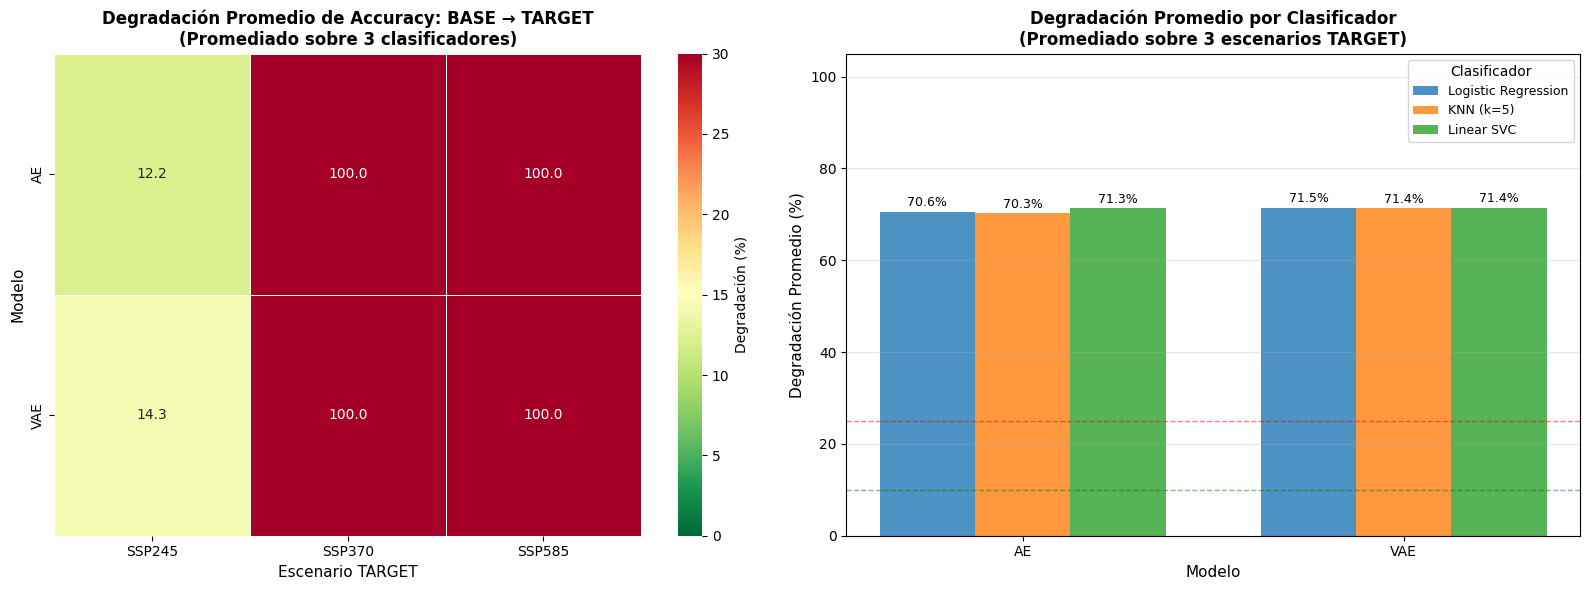

✓ Figura guardada: latent_classifier_degradation.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel 1: Heatmap de degradación por modelo y escenario (promediado sobre clasificadores)
ax = axes[0]
df_pivot = df_summary.pivot_table(
    index='Model',
    columns='Target',
    values='Degradation_%',
    aggfunc='mean'
)

sns.heatmap(
    df_pivot,
    annot=True,
    fmt='.1f',
    cmap='RdYlGn_r',
    center=15,
    vmin=0,
    vmax=30,
    cbar_kws={'label': 'Degradación (%)'},
    ax=ax,
    linewidths=0.5
)

ax.set_title('Degradación Promedio de Accuracy: BASE → TARGET\n(Promediado sobre 3 clasificadores)', 
             fontsize=12, fontweight='bold')
ax.set_xlabel('Escenario TARGET', fontsize=11)
ax.set_ylabel('Modelo', fontsize=11)

# Panel 2: Barras agrupadas por clasificador
ax = axes[1]

x = np.arange(len(MODEL_ORDER))
width = 0.25

for i, clf_name in enumerate(classifier_types.keys()):
    df_clf = df_summary[df_summary['Classifier'] == clf_name]
    
    # Promediar degradación por modelo
    degrad_means = []
    for model_key in MODEL_ORDER:
        mean_deg = df_clf[df_clf['Model'] == model_key]['Degradation_%'].mean()
        degrad_means.append(mean_deg)
    
    offset = (i - 1) * width
    bars = ax.bar(x + offset, degrad_means, width, label=clf_name, alpha=0.8)
    
    # Añadir valores
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                f'{height:.1f}%', ha='center', va='bottom', fontsize=9)

ax.set_xlabel('Modelo', fontsize=11)
ax.set_ylabel('Degradación Promedio (%)', fontsize=11)
ax.set_title('Degradación Promedio por Clasificador\n(Promediado sobre 3 escenarios TARGET)', 
             fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(MODEL_ORDER)
ax.legend(title='Clasificador', fontsize=9)
ax.axhline(y=10, color='green', linestyle='--', linewidth=1, alpha=0.5, label='Preservada (<10%)')
ax.axhline(y=25, color='red', linestyle='--', linewidth=1, alpha=0.5, label='Cambió (>25%)')
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, max(df_summary['Degradation_%'].max() + 5, 30))

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'latent_classifier_degradation.png'), dpi=300, bbox_inches='tight')
plt.show()

print("✓ Figura guardada: latent_classifier_degradation.png")

## Caracterización Climática por Cluster

Análisis de las variables climáticas promedio para cada cluster.

In [40]:
from sklearn.preprocessing import StandardScaler

def characterize_clusters(model_key, X_data, labels, feature_names):
    """
    Calcula estadísticos por cluster para todas las variables climáticas.
    
    Args:
        model_key: Nombre del modelo (AE o VAE)
        X_data: Datos climáticos (n_pixels, n_features)
        labels: Labels de cluster (n_pixels,)
        feature_names: Nombres de las features
        
    Returns:
        DataFrame con caracterización por cluster
    """
    
    profiles = []
    
    for cluster_id in range(K_CLUSTERS):
        mask = labels == cluster_id
        n_pixels = mask.sum()
        
        if n_pixels == 0:
            continue
        
        X_cluster = X_data[mask]
        
        profile = {
            "model": model_key,
            "cluster_id": cluster_id,
            "n_pixels": n_pixels,
            "pct_pixels": n_pixels / len(labels) * 100
        }
        
        for i, var_name in enumerate(feature_names):
            values = X_cluster[:, i]
            profile[f"{var_name}_mean"] = values.mean()
            profile[f"{var_name}_std"] = values.std()
            profile[f"{var_name}_min"] = values.min()
            profile[f"{var_name}_max"] = values.max()
            profile[f"{var_name}_p25"] = np.percentile(values, 25)
            profile[f"{var_name}_p50"] = np.percentile(values, 50)
            profile[f"{var_name}_p75"] = np.percentile(values, 75)
        
        profiles.append(profile)
    
    return pd.DataFrame(profiles)


CLUSTER_PROFILES = {}

for model_key in MODEL_ORDER:
    print(f"\nCaracterizando clusters — {model_key}")
    
    results = CLUSTERING_RESULTS[model_key]
    labels_base = results["labels_base"]
    
    labels_B245 = labels_base[:N_PER_SCENARIO]
    
    print(f"\nDimensiones:")
    print(f"  X_BASE: {X_BASE.shape} (features usadas para clustering)")
    print(f"  X245_orig: {X245_orig.shape} (todas las variables originales)")
    print(f"  feature_names: {len(feature_names)} variables")
    
    print(f"\nUsando X245_orig para caracterización completa de variables...")
    df_profile = characterize_clusters(model_key, X245_orig, labels_B245, feature_names)
    CLUSTER_PROFILES[model_key] = df_profile
    
    print(f"  Clusters caracterizados: {len(df_profile)}")
    print(f"\n{df_profile[['cluster_id', 'n_pixels', 'pct_pixels']].to_string(index=False)}")

print("\n✓ Perfiles de clusters creados")


Caracterizando clusters — AE

Dimensiones:
  X_BASE: (1983, 29) (features usadas para clustering)
  X245_orig: (661, 47) (todas las variables originales)
  feature_names: 47 variables

Usando X245_orig para caracterización completa de variables...
  Clusters caracterizados: 3

 cluster_id  n_pixels  pct_pixels
          0       154   23.298033
          3       197   29.803328
          5       310   46.898638

Caracterizando clusters — VAE

Dimensiones:
  X_BASE: (1983, 29) (features usadas para clustering)
  X245_orig: (661, 47) (todas las variables originales)
  feature_names: 47 variables

Usando X245_orig para caracterización completa de variables...
  Clusters caracterizados: 3

 cluster_id  n_pixels  pct_pixels
          0       232   35.098336
          1       201   30.408472
          9       228   34.493192

✓ Perfiles de clusters creados


## Caracterización Climática por Cluster - TARGET (Futuros)

Análisis de las variables climáticas promedio para clusters en períodos TARGET (2090-2100) por escenario SSP.

In [41]:
CLUSTER_PROFILES_TARGET = {
    "SSP245": {},
    "SSP370": {},
    "SSP585": {}
}

for model_key in MODEL_ORDER:
    print(f"\n{'='*60}")
    print(f"Caracterizando clusters TARGET — {model_key}")
    print(f"{'='*60}")
    
    results = CLUSTERING_RESULTS[model_key]
    labels_T245 = results["labels_T245"]
    labels_T370 = results["labels_T370"]
    labels_T585 = results["labels_T585"]
    
    # SSP245
    print(f"\nSSP245 TARGET (2090-2100):")
    df_profile_T245 = characterize_clusters(model_key, X245_orig, labels_T245, feature_names)
    CLUSTER_PROFILES_TARGET["SSP245"][model_key] = df_profile_T245
    print(f"  Clusters caracterizados: {len(df_profile_T245)}")
    print(f"\n{df_profile_T245[['cluster_id', 'n_pixels', 'pct_pixels']].to_string(index=False)}")
    
    # SSP370
    print(f"\nSSP370 TARGET (2090-2100):")
    df_profile_T370 = characterize_clusters(model_key, X370_orig, labels_T370, feature_names)
    CLUSTER_PROFILES_TARGET["SSP370"][model_key] = df_profile_T370
    print(f"  Clusters caracterizados: {len(df_profile_T370)}")
    print(f"\n{df_profile_T370[['cluster_id', 'n_pixels', 'pct_pixels']].to_string(index=False)}")
    
    # SSP585
    print(f"\nSSP585 TARGET (2090-2100):")
    df_profile_T585 = characterize_clusters(model_key, X585_orig, labels_T585, feature_names)
    CLUSTER_PROFILES_TARGET["SSP585"][model_key] = df_profile_T585
    print(f"  Clusters caracterizados: {len(df_profile_T585)}")
    print(f"\n{df_profile_T585[['cluster_id', 'n_pixels', 'pct_pixels']].to_string(index=False)}")

print("\n✓ Perfiles de clusters TARGET creados para todos los escenarios")


Caracterizando clusters TARGET — AE

SSP245 TARGET (2090-2100):
  Clusters caracterizados: 5

 cluster_id  n_pixels  pct_pixels
          0        90   13.615734
          2         1    0.151286
          3       219   33.131619
          5       333   50.378215
          7        18    2.723147

SSP370 TARGET (2090-2100):
  Clusters caracterizados: 3

 cluster_id  n_pixels  pct_pixels
          1       142   21.482602
          4       337   50.983359
          6       182   27.534039

SSP585 TARGET (2090-2100):
  Clusters caracterizados: 4

 cluster_id  n_pixels  pct_pixels
          2       165   24.962179
          7       103   15.582451
          8       217   32.829047
          9       176   26.626324

Caracterizando clusters TARGET — VAE

SSP245 TARGET (2090-2100):
  Clusters caracterizados: 3

 cluster_id  n_pixels  pct_pixels
          0       292   44.175492
          1       238   36.006051
          9       131   19.818457

SSP370 TARGET (2090-2100):
  Clusters caracter

## Función de Firma Climática por Cluster

Función para calcular z-scores de cada cluster respecto al conjunto BASE completo.

In [42]:
def cluster_signature(df, cols, id='cluster_id'):
    """
    Calcula firmas climáticas (z-scores) de cada cluster respecto al conjunto BASE completo.
    
    La firma representa cuánto se desvía cada cluster del promedio global en cada variable.
    Z-scores positivos indican valores por encima del promedio, negativos por debajo.
    
    Args:
        df: DataFrame con perfiles de clusters (debe incluir columna id y cols)
        cols: Lista de columnas (variables climáticas) para calcular firmas
        id: Nombre de la columna identificadora de clusters (default: 'cluster_id')
        
    Returns:
        DataFrame con cluster_id y firmas z-score por variable
        
    Interpretación:
        - z > 1.5: Valor muy por encima del promedio
        - 0.5 < z <= 1.5: Por encima del promedio
        - -0.5 < z <= 0.5: Cercano al promedio
        - -1.5 < z <= -0.5: Por debajo del promedio
        - z <= -1.5: Valor muy por debajo del promedio
    """
    
    # Validar columnas
    missing_cols = [col for col in cols if col not in df.columns]
    if missing_cols:
        raise ValueError(f"Columnas faltantes en df: {missing_cols}")
    
    if id not in df.columns:
        raise ValueError(f"Columna identificadora '{id}' no encontrada en df")
    
    # Calcular estadísticos globales (BASE completo)
    global_mean = df[cols].mean()
    global_std = df[cols].std()
    
    # Calcular z-scores para cada cluster
    signatures = []
    
    for _, row in df.iterrows():
        sig = {id: row[id]}
        
        for col in cols:
            # Z-score: (valor_cluster - media_global) / std_global
            if global_std[col] > 0:
                z_score = (row[col] - global_mean[col]) / global_std[col]
            else:
                # Si std = 0, todos los valores son iguales (z = 0)
                z_score = 0.0
            
            sig[col] = z_score
        
        signatures.append(sig)
    
    return pd.DataFrame(signatures)


# Ejemplo de uso: calcular firmas BASE para AE
print("Ejemplo: Firmas climáticas BASE - AE")
print("\nColumnas disponibles:")
mean_cols = [col for col in CLUSTER_PROFILES["AE"].columns if col.endswith("_mean")]
print(f"  Total: {len(mean_cols)} variables _mean")

# Calcular firmas para todas las variables _mean
df_sig_ae = cluster_signature(CLUSTER_PROFILES["AE"], mean_cols)

print(f"\nResultado:")
print(f"  Shape: {df_sig_ae.shape}")
print(f"\nPrimeras 3 filas (primeras 8 columnas):")
print(df_sig_ae.iloc[:3, :8].to_string(index=False))

print("\n✓ Función cluster_signature implementada")

Ejemplo: Firmas climáticas BASE - AE

Columnas disponibles:
  Total: 47 variables _mean

Resultado:
  Shape: (3, 48)

Primeras 3 filas (primeras 8 columnas):
 cluster_id  calliope_cf_mean_mean  calliope_cap_electrolyzer_mw_mean  topo_slope_mean  topo_elevation_mean  landuse_suitable_pv_mean  landuse_restricted_mean  landuse_agriculture_mean
          0              -0.810214                          -1.149535        -1.009976            -0.780873                 -1.154677                -0.009125                  0.954464
          3              -0.307399                           0.669254         0.989716             1.127103                  0.570968                -0.995406                 -1.040037
          5               1.117613                           0.480279         0.020259            -0.346230                  0.583709                 1.004531                  0.085573

✓ Función cluster_signature implementada


In [43]:
def signature_similarity(sig_base, sig_target, metric='cosine'):
    """
    Calcula similitud entre firmas climáticas de clusters BASE y TARGET.
    
    Mide qué tan similar es el patrón climático de un cluster entre BASE y TARGET.
    Un valor cercano a 1 indica que el cluster mantiene su perfil climático relativo.
    Un valor cercano a -1 indica perfiles opuestos (raro en clima).
    Un valor cercano a 0 indica patrones ortogonales (cambio significativo).
    
    Args:
        sig_base: Series o array con z-scores de firma BASE (solo valores numéricos)
        sig_target: Series o array con z-scores de firma TARGET (mismas columnas/orden)
        metric: Métrica de similitud ('cosine' por defecto)
        
    Returns:
        float: Similitud en rango [-1, 1]
            - 1.0: Perfiles idénticos (máxima similitud)
            - 0.5-0.9: Alta similitud (cambio moderado)
            - 0.0-0.5: Similitud baja (cambio considerable)
            - < 0.0: Perfiles opuestos (raro, indica inversión de condiciones)
            
    Interpretación:
        - Alta similitud (>0.7): El cluster mantiene su caracterización climática
        - Similitud media (0.4-0.7): Cambios moderados en condiciones climáticas
        - Baja similitud (<0.4): Transformación significativa del perfil climático
    """
    from sklearn.metrics.pairwise import cosine_similarity
    
    # Convertir a arrays numpy si son Series
    if isinstance(sig_base, pd.Series):
        sig_base = sig_base.values
    if isinstance(sig_target, pd.Series):
        sig_target = sig_target.values
    
    # Validar que tengan la misma longitud
    if len(sig_base) != len(sig_target):
        raise ValueError(f"Las firmas deben tener la misma longitud: {len(sig_base)} vs {len(sig_target)}")
    
    # Calcular similitud según métrica
    if metric == 'cosine':
        # Reshape para sklearn (necesita forma 2D)
        sig_base_2d = sig_base.reshape(1, -1)
        sig_target_2d = sig_target.reshape(1, -1)
        
        # Cosine similarity
        similarity = cosine_similarity(sig_base_2d, sig_target_2d)[0, 0]
        
    else:
        raise ValueError(f"Métrica '{metric}' no soportada. Use 'cosine'.")
    
    return similarity


# Ejemplo de uso: comparar firmas de un cluster entre BASE y TARGET
print("Ejemplo: Similitud de firmas BASE vs TARGET - AE")

# Obtener columnas de variables
mean_cols = [col for col in CLUSTER_PROFILES["AE"].columns if col.endswith("_mean")]

# Calcular firmas BASE
sig_base_ae = cluster_signature(CLUSTER_PROFILES["AE"], mean_cols)

# Calcular firmas TARGET SSP245
sig_target_ae_245 = cluster_signature(CLUSTER_PROFILES_TARGET["SSP245"]["AE"], mean_cols)

# Comparar cluster 0 BASE vs TARGET
cluster_id = 0

if cluster_id in sig_base_ae["cluster_id"].values and cluster_id in sig_target_ae_245["cluster_id"].values:
    # Extraer solo las columnas de variables (excluir cluster_id)
    sig_b = sig_base_ae[sig_base_ae["cluster_id"] == cluster_id][mean_cols].iloc[0]
    sig_t = sig_target_ae_245[sig_target_ae_245["cluster_id"] == cluster_id][mean_cols].iloc[0]
    
    sim = signature_similarity(sig_b, sig_t, metric='cosine')
    
    print(f"\nCluster {cluster_id}:")
    print(f"  Similitud BASE → TARGET (SSP245): {sim:.4f}")
    
    if sim > 0.7:
        print(f"  → Alta similitud: mantiene caracterización climática")
    elif sim > 0.4:
        print(f"  → Similitud media: cambios moderados")
    else:
        print(f"  → Baja similitud: transformación significativa")
else:
    print(f"\nCluster {cluster_id} no encontrado en BASE o TARGET")

print("\n✓ Función signature_similarity implementada")

Ejemplo: Similitud de firmas BASE vs TARGET - AE

Cluster 0:
  Similitud BASE → TARGET (SSP245): 0.7164
  → Alta similitud: mantiene caracterización climática

✓ Función signature_similarity implementada


## Hungarian Matching para Mapeo BASE → TARGET

Usa Hungarian algorithm para encontrar el mapeo óptimo uno-a-uno entre clusters BASE y TARGET basado en Jaccard similarity.

In [44]:
def hungarian_cluster_matching(M_jaccard, labels_base, labels_target):
    """
    Encuentra mapeo óptimo uno-a-uno entre clusters BASE y TARGET usando Hungarian algorithm.
    
    Minimiza el costo (1 - Jaccard) para maximizar la similitud de pixeles compartidos.
    Útil para rastrear cómo evolucionan los clusters entre períodos temporales.
    
    Args:
        M_jaccard: Matriz de Jaccard similarity (K_base × K_target)
        labels_base: Array con labels de clusters BASE (n_pixels,)
        labels_target: Array con labels de clusters TARGET (n_pixels,)
        
    Returns:
        list: Lista de tuplas (c_base, c_target, jaccard, retention) donde:
            - c_base: ID del cluster BASE
            - c_target: ID del cluster TARGET emparejado
            - jaccard: Similitud de Jaccard entre ambos clusters
            - retention: % de pixeles del cluster BASE que permanecen en c_target
            
    Interpretación:
        - jaccard > 0.5: Alta retención espacial (mismo territorio)
        - jaccard 0.3-0.5: Retención moderada (migración parcial)
        - jaccard < 0.3: Baja retención (cambio significativo de territorio)
        - retention: Indica qué % del cluster BASE "sobrevive" en el cluster TARGET
    """
    from scipy.optimize import linear_sum_assignment
    
    # Convertir similitud a costo (minimizar 1 - Jaccard)
    cost_matrix = 1.0 - M_jaccard
    
    # Hungarian algorithm: encuentra asignación de costo mínimo
    row_indices, col_indices = linear_sum_assignment(cost_matrix)
    
    # Construir lista de pares con métricas
    pairs = []
    
    for c_base, c_target in zip(row_indices, col_indices):
        jaccard = M_jaccard[c_base, c_target]
        
        # Calcular retention: % de pixeles BASE que van a TARGET
        n_base = (labels_base == c_base).sum()
        n_intersection = ((labels_base == c_base) & (labels_target == c_target)).sum()
        
        if n_base > 0:
            retention = (n_intersection / n_base) * 100
        else:
            retention = 0.0
        
        pairs.append((int(c_base), int(c_target), float(jaccard), float(retention)))
    
    # Ordenar por Jaccard descendente (mejores matches primero)
    pairs.sort(key=lambda x: x[2], reverse=True)
    
    return pairs


# Función auxiliar para calcular matriz de Jaccard
def compute_jaccard_matrix(labels_base, labels_target, K_clusters):
    """
    Calcula matriz de similitud de Jaccard entre clusters BASE y TARGET.
    
    Jaccard(A,B) = |A ∩ B| / |A ∪ B|
    
    Args:
        labels_base: Array con labels BASE (n_pixels,)
        labels_target: Array con labels TARGET (n_pixels,)
        K_clusters: Número de clusters
        
    Returns:
        np.ndarray: Matriz K × K con valores Jaccard
    """
    M = np.zeros((K_clusters, K_clusters))
    
    for c_base in range(K_clusters):
        mask_base = labels_base == c_base
        n_base = mask_base.sum()
        
        if n_base == 0:
            continue
        
        for c_target in range(K_clusters):
            mask_target = labels_target == c_target
            n_target = mask_target.sum()
            
            if n_target == 0:
                continue
            
            # Intersección y unión
            n_intersection = (mask_base & mask_target).sum()
            n_union = (mask_base | mask_target).sum()
            
            if n_union > 0:
                M[c_base, c_target] = n_intersection / n_union
    
    return M


# Ejemplo: Hungarian matching para AE, SSP245
print("Ejemplo: Hungarian matching BASE → TARGET (SSP245) - AE")

model_key = "AE"
results = CLUSTERING_RESULTS[model_key]

labels_base = results["labels_base"][:N_PER_SCENARIO]  # Solo SSP245 BASE
labels_T245 = results["labels_T245"]

# Calcular matriz de Jaccard
M_jaccard = compute_jaccard_matrix(labels_base, labels_T245, K_CLUSTERS)

print(f"\nMatriz de Jaccard (BASE vs TARGET):")
print(f"  Shape: {M_jaccard.shape}")
print(f"  Max Jaccard: {M_jaccard.max():.4f}")
print(f"  Mean Jaccard: {M_jaccard.mean():.4f}")

# Aplicar Hungarian matching
pairs = hungarian_cluster_matching(M_jaccard, labels_base, labels_T245)

print(f"\nMapeo óptimo BASE → TARGET ({len(pairs)} pares):")
print(f"\n{'BASE':<6} {'→ TARGET':<10} {'Jaccard':<10} {'Retention %':<12} {'Calidad'}")
print("-" * 60)

for c_base, c_target, jaccard, retention in pairs:
    if jaccard > 0.5:
        quality = "Alta"
    elif jaccard > 0.3:
        quality = "Media"
    else:
        quality = "Baja"
    
    print(f"{c_base:<6} → {c_target:<10} {jaccard:<10.4f} {retention:<12.1f} {quality}")

print("\n✓ Funciones de Hungarian matching implementadas")

Ejemplo: Hungarian matching BASE → TARGET (SSP245) - AE

Matriz de Jaccard (BASE vs TARGET):
  Shape: (10, 10)
  Max Jaccard: 0.8995
  Mean Jaccard: 0.0250

Mapeo óptimo BASE → TARGET (10 pares):

BASE   → TARGET   Jaccard    Retention %  Calidad
------------------------------------------------------------
3      → 3          0.8995     100.0        Alta
5      → 5          0.7616     89.7         Alta
0      → 0          0.5844     58.4         Alta
1      → 1          0.0000     0.0          Baja
2      → 2          0.0000     0.0          Baja
4      → 4          0.0000     0.0          Baja
6      → 6          0.0000     0.0          Baja
7      → 7          0.0000     0.0          Baja
8      → 8          0.0000     0.0          Baja
9      → 9          0.0000     0.0          Baja

✓ Funciones de Hungarian matching implementadas


## Análisis de Desplazamiento de Centroides

Calcula el movimiento del centro de masa de clusters entre BASE y TARGET, normalizado por su dispersión interna.

In [45]:
def centroid_displacement_analysis(c_base, c_target, X_base, X_target, labels_base, labels_target):
    """
    Analiza el desplazamiento del centroide de un cluster entre BASE y TARGET.
    
    Calcula cuánto se movió el centro del cluster en el espacio latente/de features,
    normalizado por la dispersión interna del cluster BASE. Esto indica si el cluster
    mantiene su identidad o ha cambiado fundamentalmente de tipo.
    
    Args:
        c_base: ID del cluster en BASE
        c_target: ID del cluster en TARGET (del mapeo Hungarian)
        X_base: Datos BASE (n_pixels, n_features)
        X_target: Datos TARGET (n_pixels, n_features)
        labels_base: Labels BASE (n_pixels,)
        labels_target: Labels TARGET (n_pixels,)
        
    Returns:
        dict: Métricas de desplazamiento con:
            - displacement_abs: Distancia euclidiana entre centroides
            - displacement_norm: Desplazamiento normalizado por dispersión BASE
            - dispersion_base: Dispersión promedio (std) del cluster BASE
            - dispersion_target: Dispersión promedio del cluster TARGET
            - stability: Categoría ('Estable', 'Moderado', 'Alto desplazamiento')
            
    Interpretación:
        - displacement_norm < 0.5: Cluster estable (movimiento < 0.5 × dispersión)
        - 0.5 ≤ displacement_norm < 1.5: Desplazamiento moderado
        - displacement_norm ≥ 1.5: Alto desplazamiento (posible cambio de tipo)
        
        Clusters estables mantienen su identidad climática, mientras que alto 
        desplazamiento indica transformación del régimen.
    """
    
    # Extraer datos de cada cluster
    mask_base = labels_base == c_base
    mask_target = labels_target == c_target
    
    if mask_base.sum() == 0 or mask_target.sum() == 0:
        return None
    
    X_cluster_base = X_base[mask_base]
    X_cluster_target = X_target[mask_target]
    
    # Calcular centroides (centro de masa en espacio de features)
    centroid_base = X_cluster_base.mean(axis=0)
    centroid_target = X_cluster_target.mean(axis=0)
    
    # Validar que ambos centroides tengan la misma dimensionalidad
    if centroid_base.shape != centroid_target.shape:
        raise ValueError(
            f"Dimensiones incompatibles: centroid_base={centroid_base.shape}, "
            f"centroid_target={centroid_target.shape}. "
            f"Asegúrate de usar datos del mismo espacio de features."
        )
    
    # Desplazamiento absoluto (distancia euclidiana)
    displacement_abs = np.linalg.norm(centroid_target - centroid_base)
    
    # Dispersión del cluster BASE (std promedio en todas las features)
    dispersion_base = X_cluster_base.std(axis=0).mean()
    
    # Dispersión del cluster TARGET
    dispersion_target = X_cluster_target.std(axis=0).mean()
    
    # Desplazamiento normalizado (en unidades de dispersión)
    if dispersion_base > 0:
        displacement_norm = displacement_abs / dispersion_base
    else:
        displacement_norm = 0.0
    
    # Categoría de estabilidad
    if displacement_norm < 0.5:
        stability = "Estable"
    elif displacement_norm < 1.5:
        stability = "Moderado"
    else:
        stability = "Alto desplazamiento"
    
    return {
        "c_base": int(c_base),
        "c_target": int(c_target),
        "displacement_abs": float(displacement_abs),
        "displacement_norm": float(displacement_norm),
        "dispersion_base": float(dispersion_base),
        "dispersion_target": float(dispersion_target),
        "dispersion_change": float(dispersion_target - dispersion_base),
        "dispersion_change_pct": float((dispersion_target - dispersion_base) / dispersion_base * 100) if dispersion_base > 0 else 0.0,
        "stability": stability
    }


def analyze_all_centroids(pairs, X_base, X_target, labels_base, labels_target):
    """
    Analiza desplazamiento de centroides para todos los pares del mapeo Hungarian.
    
    Args:
        pairs: Lista de tuplas del hungarian_cluster_matching
        X_base: Datos BASE
        X_target: Datos TARGET
        labels_base: Labels BASE
        labels_target: Labels TARGET
        
    Returns:
        pd.DataFrame: Tabla con métricas de desplazamiento para cada par
    """
    
    results = []
    
    for c_base, c_target, jaccard, retention in pairs:
        analysis = centroid_displacement_analysis(
            c_base, c_target, X_base, X_target, labels_base, labels_target
        )
        
        if analysis is not None:
            # Agregar métricas de Hungarian
            analysis["jaccard"] = jaccard
            analysis["retention"] = retention
            results.append(analysis)
    
    df = pd.DataFrame(results)
    
    # Ordenar por desplazamiento normalizado (mayor cambio primero)
    df = df.sort_values("displacement_norm", ascending=False).reset_index(drop=True)
    
    return df


# Ejemplo: Análisis de desplazamiento de centroides AE, SSP245
print("Ejemplo: Análisis de desplazamiento de centroides - AE SSP245")

model_key = "AE"
results = CLUSTERING_RESULTS[model_key]

# Verificar keys disponibles en LATENTS
latent_keys = list(LATENTS[model_key].keys())
print(f"\nKeys disponibles en LATENTS['{model_key}']: {latent_keys}")

# Buscar las keys correctas (pueden ser Z_base, z_base, latent_base, etc.)
Z_base = None
Z_T245 = None

# Intentar diferentes variantes de nombres
for base_key in ["Z_base", "z_base", "latent_base", "Z_BASE"]:
    if base_key in LATENTS[model_key]:
        Z_base = LATENTS[model_key][base_key][:N_PER_SCENARIO]
        print(f"  Encontrado: {base_key} con forma {Z_base.shape}")
        break

for target_key in ["Z_T245", "z_t245", "latent_t245", "Z_t245", "latent_T245"]:
    if target_key in LATENTS[model_key]:
        Z_T245 = LATENTS[model_key][target_key]
        print(f"  Encontrado: {target_key} con forma {Z_T245.shape}")
        break

# Si no se encontraron, usar el primer par disponible que coincida en dimensiones
if Z_base is None or Z_T245 is None:
    print("\nWarning: No se encontraron keys estándar, intentando con las primeras keys disponibles...")
    
    # Buscar pares que tengan dimensiones compatibles
    for key in latent_keys:
        if Z_base is None and "base" in key.lower():
            Z_base = LATENTS[model_key][key][:N_PER_SCENARIO]
            print(f"  Usando {key} para BASE: forma {Z_base.shape}")
    
    for key in latent_keys:
        if Z_T245 is None and ("245" in key.lower() or "t245" in key.lower()):
            Z_T245 = LATENTS[model_key][key]
            print(f"  Usando {key} para TARGET: forma {Z_T245.shape}")

# Validar que tengan la misma dimensionalidad
if Z_base is not None and Z_T245 is not None:
    if Z_base.shape[1] != Z_T245.shape[1]:
        print(f"\nERROR: Dimensiones incompatibles!")
        print(f"  Z_base: {Z_base.shape}")
        print(f"  Z_T245: {Z_T245.shape}")
        print(f"  No se puede calcular desplazamiento de centroides.")
        df_displacement = None
    else:
        print(f"\n✓ Dimensiones compatibles: {Z_base.shape[1]} features")
        
        labels_base = results["labels_base"][:N_PER_SCENARIO]
        labels_T245 = results["labels_T245"]
        
        # Calcular matriz de Jaccard y Hungarian matching
        M_jaccard = compute_jaccard_matrix(labels_base, labels_T245, K_CLUSTERS)
        pairs = hungarian_cluster_matching(M_jaccard, labels_base, labels_T245)
        
        # Analizar desplazamientos
        df_displacement = analyze_all_centroids(pairs, Z_base, Z_T245, labels_base, labels_T245)
        
        print(f"\nAnálisis de desplazamiento de centroides ({len(df_displacement)} clusters):")
        print("\nColumnas clave:")
        print("  - displacement_norm: Desplazamiento / dispersión BASE")
        print("  - stability: Categoría de estabilidad del cluster")
        print("  - dispersion_change_pct: Cambio % en dispersión interna")
        print("\nTop 5 clusters con mayor desplazamiento:\n")
        
        display_cols = ["c_base", "c_target", "displacement_norm", "dispersion_change_pct", 
                        "jaccard", "retention", "stability"]
        print(df_displacement[display_cols].head(5).to_string(index=False))
        
        print("\n\nResumen por estabilidad:")
        stability_summary = df_displacement["stability"].value_counts()
        for category, count in stability_summary.items():
            pct = count / len(df_displacement) * 100
            print(f"  {category}: {count} clusters ({pct:.1f}%)")
else:
    print("\nERROR: No se pudieron cargar los datos latentes.")
    df_displacement = None

if df_displacement is not None:
    print("\n✓ Funciones de análisis de desplazamiento implementadas")
else:
    print("\n⚠ Análisis de desplazamiento no disponible con estos datos")

Ejemplo: Análisis de desplazamiento de centroides - AE SSP245

Keys disponibles en LATENTS['AE']: ['base', 'B245', 'B370', 'B585', 'T245', 'T370', 'T585']

  Usando base para BASE: forma (661, 8)
  Usando B245 para TARGET: forma (661, 8)

✓ Dimensiones compatibles: 8 features

Análisis de desplazamiento de centroides (3 clusters):

Columnas clave:
  - displacement_norm: Desplazamiento / dispersión BASE
  - stability: Categoría de estabilidad del cluster
  - dispersion_change_pct: Cambio % en dispersión interna

Top 5 clusters con mayor desplazamiento:

 c_base  c_target  displacement_norm  dispersion_change_pct  jaccard  retention stability
      0         0           1.049603             -20.117907 0.584416  58.441558  Moderado
      5         5           0.492942               1.763323 0.761644  89.677419   Estable
      3         3           0.254904               0.498595 0.899543 100.000000   Estable


Resumen por estabilidad:
  Estable: 2 clusters (66.7%)
  Moderado: 1 clusters (

## Tabla Resumen de Evolución de Clusters

Tabla comprehensiva que integra todas las métricas: Hungarian matching, firma climática, desplazamiento de centroides y variables dominantes.

In [46]:
def generate_cluster_name(cluster_id, df_profile, mean_cols):
    """
    Genera un nombre interpretativo para un cluster basado en sus variables dominantes.
    
    El nombre combina las características climáticas más distintivas (mayor z-score)
    en un formato legible: 'cálido-seco', 'templado-húmedo', 'frío-extremo', etc.
    
    Args:
        cluster_id: ID del cluster
        df_profile: DataFrame con perfiles de clusters
        mean_cols: Lista de columnas con valores _mean
        
    Returns:
        str: Nombre interpretativo del cluster
        
    Lógica de nomenclatura:
    - Selecciona las 2-3 variables con mayor z-score absoluto
    - Traduce valores z a términos cualitativos
    - Prioriza temperatura, precipitación y extremos
    """
    
    # Calcular firmas (z-scores)
    df_sig = cluster_signature(df_profile, mean_cols)
    
    if cluster_id not in df_sig["cluster_id"].values:
        return "Indefinido"
    
    # Extraer firma del cluster
    sig_row = df_sig[df_sig["cluster_id"] == cluster_id].iloc[0]
    
    # Obtener z-scores de todas las variables
    z_values = {}
    for col in mean_cols:
        var_name = col.replace("_mean", "")
        z_values[var_name] = sig_row[col]
    
    # Ordenar por valor absoluto (más distintivo primero)
    sorted_vars = sorted(z_values.items(), key=lambda x: abs(x[1]), reverse=True)
    
    # Diccionario de mapeo de variables a términos interpretativos
    # Estructura: {variable: {(z_min, z_max): 'término'}}
    
    interpretation_map = {
        # Temperatura
        'tmax': {
            (1.5, float('inf')): 'muy-cálido',
            (0.5, 1.5): 'cálido',
            (-0.5, 0.5): 'templado',
            (-1.5, -0.5): 'fresco',
            (float('-inf'), -1.5): 'frío'
        },
        'tmin': {
            (1.5, float('inf')): 'muy-cálido',
            (0.5, 1.5): 'cálido',
            (-0.5, 0.5): 'templado',
            (-1.5, -0.5): 'fresco',
            (float('-inf'), -1.5): 'frío'
        },
        'tmean': {
            (1.5, float('inf')): 'muy-cálido',
            (0.5, 1.5): 'cálido',
            (-0.5, 0.5): 'templado',
            (-1.5, -0.5): 'fresco',
            (float('-inf'), -1.5): 'frío'
        },
        
        # Precipitación
        'pr': {
            (1.5, float('inf')): 'muy-lluvioso',
            (0.5, 1.5): 'lluvioso',
            (-0.5, 0.5): 'moderado',
            (-1.5, -0.5): 'seco',
            (float('-inf'), -1.5): 'muy-seco'
        },
        
        # Sequía
        'spei12': {
            (1.0, float('inf')): 'húmedo',
            (0.3, 1.0): 'normal-húmedo',
            (-0.3, 0.3): 'normal',
            (-1.0, -0.3): 'sequía-moderada',
            (float('-inf'), -1.0): 'sequía-severa'
        },
        'spei3': {
            (1.0, float('inf')): 'húmedo',
            (0.3, 1.0): 'normal-húmedo',
            (-0.3, 0.3): 'normal',
            (-1.0, -0.3): 'sequía-moderada',
            (float('-inf'), -1.0): 'sequía-severa'
        },
        
        # Días extremos
        'tx90p': {
            (1.0, float('inf')): 'días-calurosos-frecuentes',
            (0.3, 1.0): 'días-calurosos',
            (-0.3, 0.3): 'calor-normal',
            (float('-inf'), -0.3): 'pocos-días-calurosos'
        },
        'tn10p': {
            (1.0, float('inf')): 'noches-frías-frecuentes',
            (0.3, 1.0): 'noches-frías',
            (-0.3, 0.3): 'frío-nocturno-normal',
            (float('-inf'), -0.3): 'pocas-noches-frías'
        },
        
        # Olas de calor
        'wsdi': {
            (1.0, float('inf')): 'olas-calor-frecuentes',
            (0.5, 1.0): 'olas-calor',
            (-0.5, 0.5): 'calor-sostenido-normal',
            (float('-inf'), -0.5): 'sin-olas-calor'
        },
        
        # Días sin lluvia
        'cdd': {
            (1.5, float('inf')): 'sequía-prolongada',
            (0.5, 1.5): 'períodos-secos',
            (-0.5, 0.5): 'sequedad-normal',
            (float('-inf'), -0.5): 'períodos-secos-cortos'
        },
        
        # Días con lluvia
        'r10mm': {
            (1.0, float('inf')): 'lluvias-intensas-frecuentes',
            (0.3, 1.0): 'lluvias-intensas',
            (-0.3, 0.3): 'lluvias-normales',
            (float('-inf'), -0.3): 'pocas-lluvias-intensas'
        },
        'r20mm': {
            (1.0, float('inf')): 'lluvias-torrenciales-frecuentes',
            (0.3, 1.0): 'lluvias-torrenciales',
            (-0.3, 0.3): 'lluvias-fuertes-normales',
            (float('-inf'), -0.3): 'pocas-lluvias-torrenciales'
        },
        
        # Rango térmico
        'dtr': {
            (1.0, float('inf')): 'oscilación-térmica-alta',
            (0.3, 1.0): 'oscilación-térmica-moderada',
            (-0.3, 0.3): 'oscilación-térmica-normal',
            (float('-inf'), -0.3): 'oscilación-térmica-baja'
        }
    }
    
    # Extraer términos de las variables más distintivas
    descriptors = []
    used_categories = set()  # Para evitar redundancia (e.g., no usar tmax y tmin)
    
    for var_name, z_score in sorted_vars[:6]:  # Revisar top 6 variables
        # Categorías de variables (para evitar redundancia)
        if var_name in ['tmax', 'tmin', 'tmean']:
            category = 'temperatura'
        elif var_name in ['pr', 'spei12', 'spei3', 'cdd']:
            category = 'precipitacion'
        elif var_name in ['tx90p', 'tn10p', 'wsdi']:
            category = 'extremos_calor'
        elif var_name in ['r10mm', 'r20mm']:
            category = 'precipitacion_intensa'
        else:
            category = var_name
        
        # Si ya tenemos un descriptor de esta categoría, skip
        if category in used_categories and len(descriptors) >= 2:
            continue
        
        # Buscar interpretación
        if var_name in interpretation_map:
            for (z_min, z_max), term in interpretation_map[var_name].items():
                if z_min <= z_score < z_max:
                    descriptors.append(term)
                    used_categories.add(category)
                    break
        
        # Limitar a 2-3 descriptores
        if len(descriptors) >= 3:
            break
    
    # Construir nombre
    if len(descriptors) == 0:
        return "Neutral"
    elif len(descriptors) == 1:
        return descriptors[0].replace('-', ' ').title()
    else:
        # Unir con guiones, capitalizando
        name = '-'.join(descriptors[:3])
        return name.replace('_', '-')


def get_top_defining_variables(cluster_id, df_profile, mean_cols, top_n=3):
    """
    Identifica las variables más distintivas de un cluster (mayor z-score absoluto).
    
    Args:
        cluster_id: ID del cluster
        df_profile: DataFrame con perfiles de clusters
        mean_cols: Lista de columnas con valores _mean
        top_n: Número de variables top a retornar
        
    Returns:
        str: String con las top N variables y sus z-scores
    """
    # Calcular firmas (z-scores)
    df_sig = cluster_signature(df_profile, mean_cols)
    
    if cluster_id not in df_sig["cluster_id"].values:
        return "N/A"
    
    # Extraer firma del cluster
    sig_row = df_sig[df_sig["cluster_id"] == cluster_id].iloc[0]
    
    # Obtener z-scores de todas las variables
    z_values = {}
    for col in mean_cols:
        z_values[col.replace("_mean", "")] = sig_row[col]
    
    # Ordenar por valor absoluto (mayor desviación = más distintivo)
    sorted_vars = sorted(z_values.items(), key=lambda x: abs(x[1]), reverse=True)
    
    # Formatear top N
    top_vars = []
    for var, z in sorted_vars[:top_n]:
        sign = "+" if z > 0 else ""
        top_vars.append(f"{var} ({sign}{z:.2f}σ)")
    
    return ", ".join(top_vars)


def cluster_evolution_summary(
    model_key, 
    scenario, 
    CLUSTERING_RESULTS, 
    LATENTS,
    CLUSTER_PROFILES,
    CLUSTER_PROFILES_TARGET,
    K_CLUSTERS,
    N_PER_SCENARIO,
    feature_names
):
    """
    Genera tabla resumen de resiliencia climática por cluster.
    
    Combina todas las métricas:
    - Hungarian matching (emparejamiento BASE → TARGET)
    - Firma climática (similitud de patrón)
    - Desplazamiento de centroides (movimiento espacial)
    - Cambio en dispersión (expansión/contracción)
    - Variables dominantes (identidad climática)
    
    Args:
        model_key: Modelo (AE/VAE)
        scenario: Escenario SSP (SSP245/SSP370/SSP585)
        CLUSTERING_RESULTS: Dict con resultados de clustering
        LATENTS: Dict con espacios latentes
        CLUSTER_PROFILES: Dict con perfiles BASE
        CLUSTER_PROFILES_TARGET: Dict con perfiles TARGET
        K_CLUSTERS: Número de clusters
        N_PER_SCENARIO: Píxeles por escenario
        feature_names: Lista de nombres de variables
        
    Returns:
        pd.DataFrame: Tabla resumen ordenada por estabilidad
    """
    
    results = CLUSTERING_RESULTS[model_key]
    
    # 1. Obtener labels
    labels_base = results["labels_base"][:N_PER_SCENARIO]
    
    if scenario == "SSP245":
        labels_target = results["labels_T245"]
        scenario_key = "SSP245"
        search_keys = ["T245", "t245", "245"]
    elif scenario == "SSP370":
        labels_target = results["labels_T370"]
        scenario_key = "SSP370"
        search_keys = ["T370", "t370", "370"]
    elif scenario == "SSP585":
        labels_target = results["labels_T585"]
        scenario_key = "SSP585"
        search_keys = ["T585", "t585", "585"]
    else:
        raise ValueError(f"Escenario '{scenario}' no reconocido")
    
    # 2. Hungarian matching (Jaccard + retention)
    M_jaccard = compute_jaccard_matrix(labels_base, labels_target, K_CLUSTERS)
    pairs = hungarian_cluster_matching(M_jaccard, labels_base, labels_target)
    
    # 3. Buscar datos latentes para desplazamiento
    latent_keys = list(LATENTS[model_key].keys())
    
    Z_base = None
    Z_target = None
    
    # Buscar BASE
    for key in latent_keys:
        if "base" in key.lower():
            Z_base = LATENTS[model_key][key][:N_PER_SCENARIO]
            break
    
    # Buscar TARGET
    for key in latent_keys:
        for search_key in search_keys:
            if search_key in key.lower():
                Z_target = LATENTS[model_key][key]
                break
        if Z_target is not None:
            break
    
    # 4. Calcular desplazamientos si hay datos latentes
    if Z_base is not None and Z_target is not None and Z_base.shape[1] == Z_target.shape[1]:
        df_displacement = analyze_all_centroids(pairs, Z_base, Z_target, labels_base, labels_target)
        has_displacement = True
    else:
        has_displacement = False
    
    # 5. Calcular similitud de firmas
    mean_cols = [col for col in CLUSTER_PROFILES[model_key].columns if col.endswith("_mean")]
    
    sig_base = cluster_signature(CLUSTER_PROFILES[model_key], mean_cols)
    sig_target = cluster_signature(CLUSTER_PROFILES_TARGET[scenario_key][model_key], mean_cols)
    
    # 6. Construir tabla resumen
    summary_rows = []
    
    for c_base, c_target, jaccard, retention in pairs:
        row = {
            "cluster_base": int(c_base),
            "cluster_target": int(c_target),
            "match_quality": "Alta" if jaccard > 0.5 else ("Media" if jaccard > 0.3 else "Baja"),
            "jaccard": float(jaccard),
            "retention_pct": float(retention),
            "n_pixels_base": int((labels_base == c_base).sum()),
            "n_pixels_target": int((labels_target == c_target).sum())
        }
        
        # Cambio en tamaño del cluster
        size_change = row["n_pixels_target"] - row["n_pixels_base"]
        size_change_pct = (size_change / row["n_pixels_base"] * 100) if row["n_pixels_base"] > 0 else 0
        row["size_change_pct"] = float(size_change_pct)
        
        if size_change_pct > 10:
            row["size_evolution"] = "Expansión"
        elif size_change_pct < -10:
            row["size_evolution"] = "Contracción"
        else:
            row["size_evolution"] = "Estable"
        
        # Similitud de firmas
        if c_base in sig_base["cluster_id"].values and c_target in sig_target["cluster_id"].values:
            sig_b = sig_base[sig_base["cluster_id"] == c_base][mean_cols].iloc[0]
            sig_t = sig_target[sig_target["cluster_id"] == c_target][mean_cols].iloc[0]
            
            sim = signature_similarity(sig_b, sig_t, metric='cosine')
            row["signature_similarity"] = float(sim)
            
            if sim > 0.7:
                row["signature_status"] = "Mantiene perfil"
            elif sim > 0.4:
                row["signature_status"] = "Cambio moderado"
            else:
                row["signature_status"] = "Transformación"
        else:
            row["signature_similarity"] = None
            row["signature_status"] = "N/A"
        
        # Desplazamiento de centroides (si disponible)
        if has_displacement:
            disp_row = df_displacement[df_displacement["c_base"] == c_base]
            if len(disp_row) > 0:
                row["displacement_norm"] = float(disp_row["displacement_norm"].iloc[0])
                row["dispersion_change_pct"] = float(disp_row["dispersion_change_pct"].iloc[0])
                row["centroid_stability"] = disp_row["stability"].iloc[0]
            else:
                row["displacement_norm"] = None
                row["dispersion_change_pct"] = None
                row["centroid_stability"] = "N/A"
        else:
            row["displacement_norm"] = None
            row["dispersion_change_pct"] = None
            row["centroid_stability"] = "N/A"
        
        # Nombre interpretativo del cluster BASE
        row["cluster_name"] = generate_cluster_name(c_base, CLUSTER_PROFILES[model_key], mean_cols)
        
        # Variables dominantes del cluster BASE (versión técnica)
        row["defining_variables"] = get_top_defining_variables(
            c_base, CLUSTER_PROFILES[model_key], mean_cols, top_n=3
        )
        
        # Score de estabilidad global (combina métricas)
        # Score alto = alta estabilidad (retención alta, firma similar, centroide estable)
        stability_score = 0
        
        # Componente 1: Retención espacial (0-40 puntos)
        stability_score += min(retention / 100 * 40, 40)
        
        # Componente 2: Similitud de firma (0-30 puntos)
        if row["signature_similarity"] is not None:
            stability_score += row["signature_similarity"] * 30
        
        # Componente 3: Estabilidad de centroide (0-30 puntos)
        if row["centroid_stability"] == "Estable":
            stability_score += 30
        elif row["centroid_stability"] == "Moderado":
            stability_score += 15
        
        row["stability_score"] = float(stability_score)
        
        # Categoría de estabilidad
        if stability_score >= 70:
            row["stability_category"] = "Alta"
        elif stability_score >= 40:
            row["stability_category"] = "Media"
        else:
            row["stability_category"] = "Baja"
        
        summary_rows.append(row)
    
    df_summary = pd.DataFrame(summary_rows)
    
    # Ordenar por resiliencia (mayor primero)
    df_summary = df_summary.sort_values("resilience_score", ascending=False).reset_index(drop=True)
    
    return df_summary


# Ejemplo: Generar tabla resumen para AE SSP245
print("Generando tabla resumen de resiliencia - AE SSP245")

df_resilience_summary = cluster_resilience_summary(
    model_key="AE",
    scenario="SSP245",
    CLUSTERING_RESULTS=CLUSTERING_RESULTS,
    LATENTS=LATENTS,
    CLUSTER_PROFILES=CLUSTER_PROFILES,
    CLUSTER_PROFILES_TARGET=CLUSTER_PROFILES_TARGET,
    K_CLUSTERS=K_CLUSTERS,
    N_PER_SCENARIO=N_PER_SCENARIO,
    feature_names=feature_names
)

print(f"\nTabla de resiliencia generada: {len(df_resilience_summary)} clusters")
print("\nColumnas disponibles:")
for col in df_resilience_summary.columns:
    print(f"  - {col}")

print("\n" + "="*120)
print("RESUMEN DE RESILIENCIA CLIMÁTICA POR CLUSTER")
print(f"Modelo: AE | Escenario: SSP245 | BASE (2020-2029) → TARGET (2090-2100)")
print("="*120)

# Mostrar tabla completa con columnas clave
display_cols = [
    "cluster_base", "cluster_name", "resilience_category", "resilience_score",
    "retention_pct", "signature_similarity", "centroid_stability",
    "size_evolution", "defining_variables"
]

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 80)

print(df_resilience_summary[display_cols].to_string(index=False))

print("\n" + "="*120)
print("RESUMEN POR CATEGORÍA DE RESILIENCIA")
print("="*120)

resilience_counts = df_resilience_summary["resilience_category"].value_counts()
for category in ["Alta", "Media", "Baja"]:
    if category in resilience_counts.index:
        count = resilience_counts[category]
        pct = count / len(df_resilience_summary) * 100
        print(f"  {category}: {count} clusters ({pct:.1f}%)")

print("\n✓ Tabla resumen de resiliencia implementada")

Generando tabla resumen de resiliencia - AE SSP245

Tabla de resiliencia generada: 10 clusters

Columnas disponibles:
  - cluster_base
  - cluster_target
  - match_quality
  - jaccard
  - retention_pct
  - n_pixels_base
  - n_pixels_target
  - size_change_pct
  - size_evolution
  - signature_similarity
  - signature_status
  - displacement_norm
  - dispersion_change_pct
  - centroid_stability
  - cluster_name
  - defining_variables
  - resilience_score
  - resilience_category

RESUMEN DE RESILIENCIA CLIMÁTICA POR CLUSTER
Modelo: AE | Escenario: SSP245 | BASE (2020-2029) → TARGET (2090-2100)
 cluster_base cluster_name resilience_category  resilience_score  retention_pct  signature_similarity centroid_stability size_evolution                                                                                                defining_variables
            3      Neutral                Alta         98.656632     100.000000              0.955221            Estable      Expansión                 

## Visualización: Heatmaps BASE vs TARGET

Heatmaps comparativos mostrando cómo cambian los perfiles climáticos de cada cluster entre BASE y TARGET por escenario.


Comparaciones BASE vs TARGET — AE

SSP245:


/tmp/ipykernel_65999/3399713422.py:84: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.96])


  Guardado: cluster_comparison_ssp245_ae_k10.png


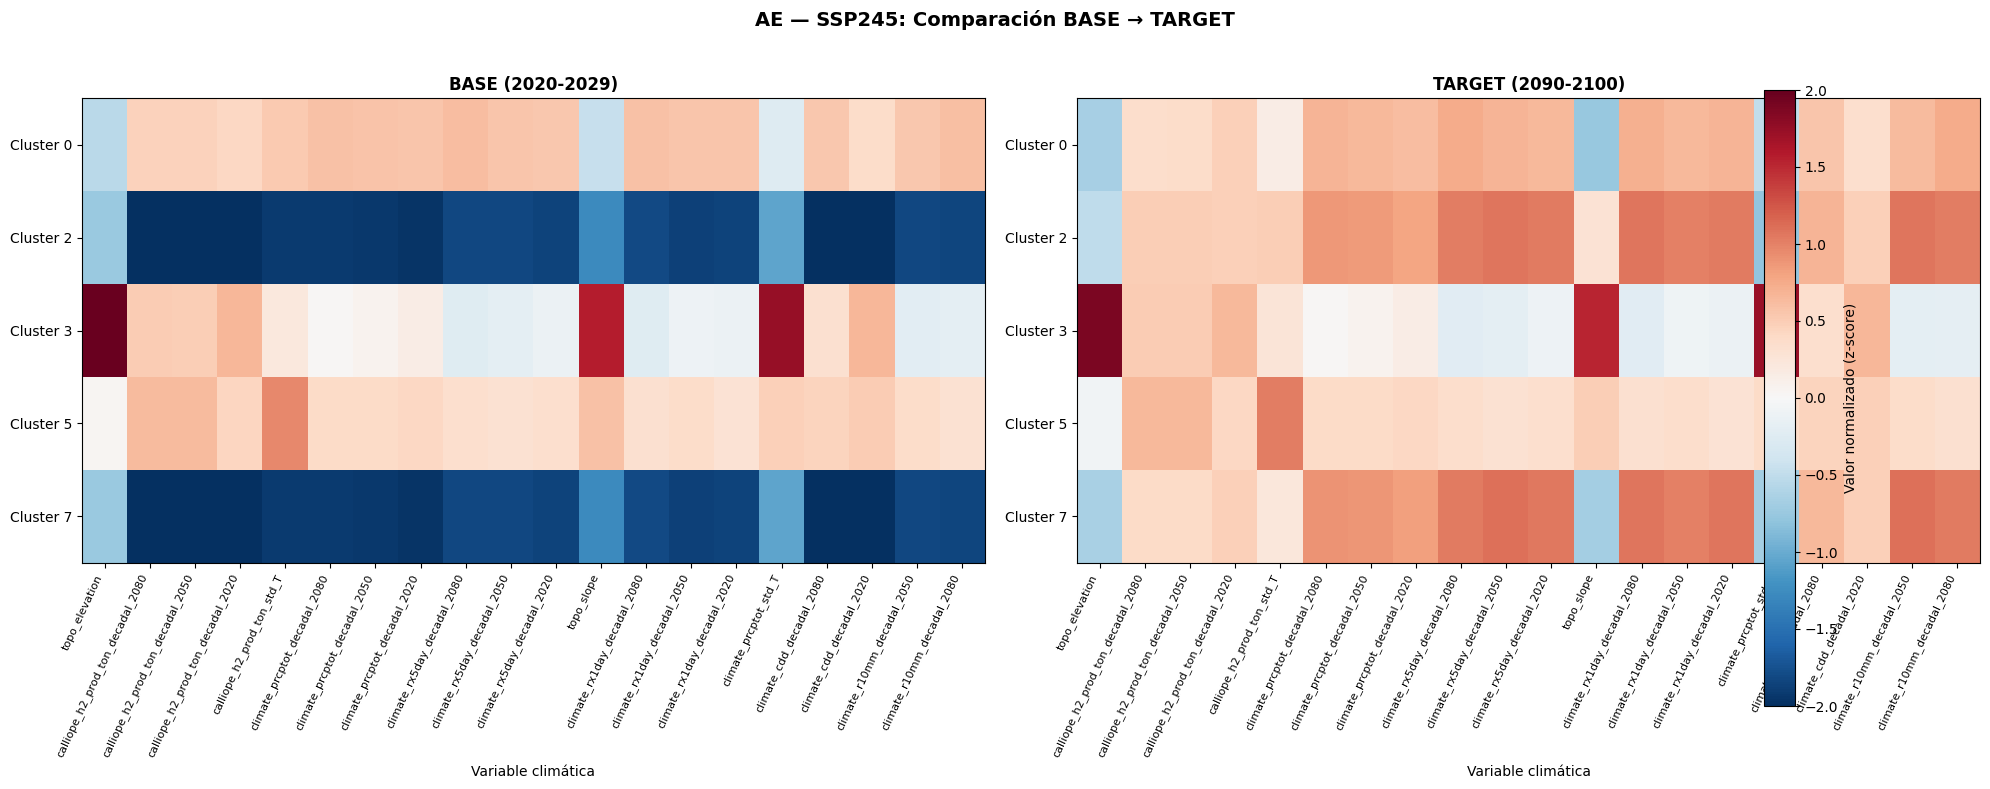


SSP370:


/tmp/ipykernel_65999/3399713422.py:84: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.96])


  Guardado: cluster_comparison_ssp370_ae_k10.png


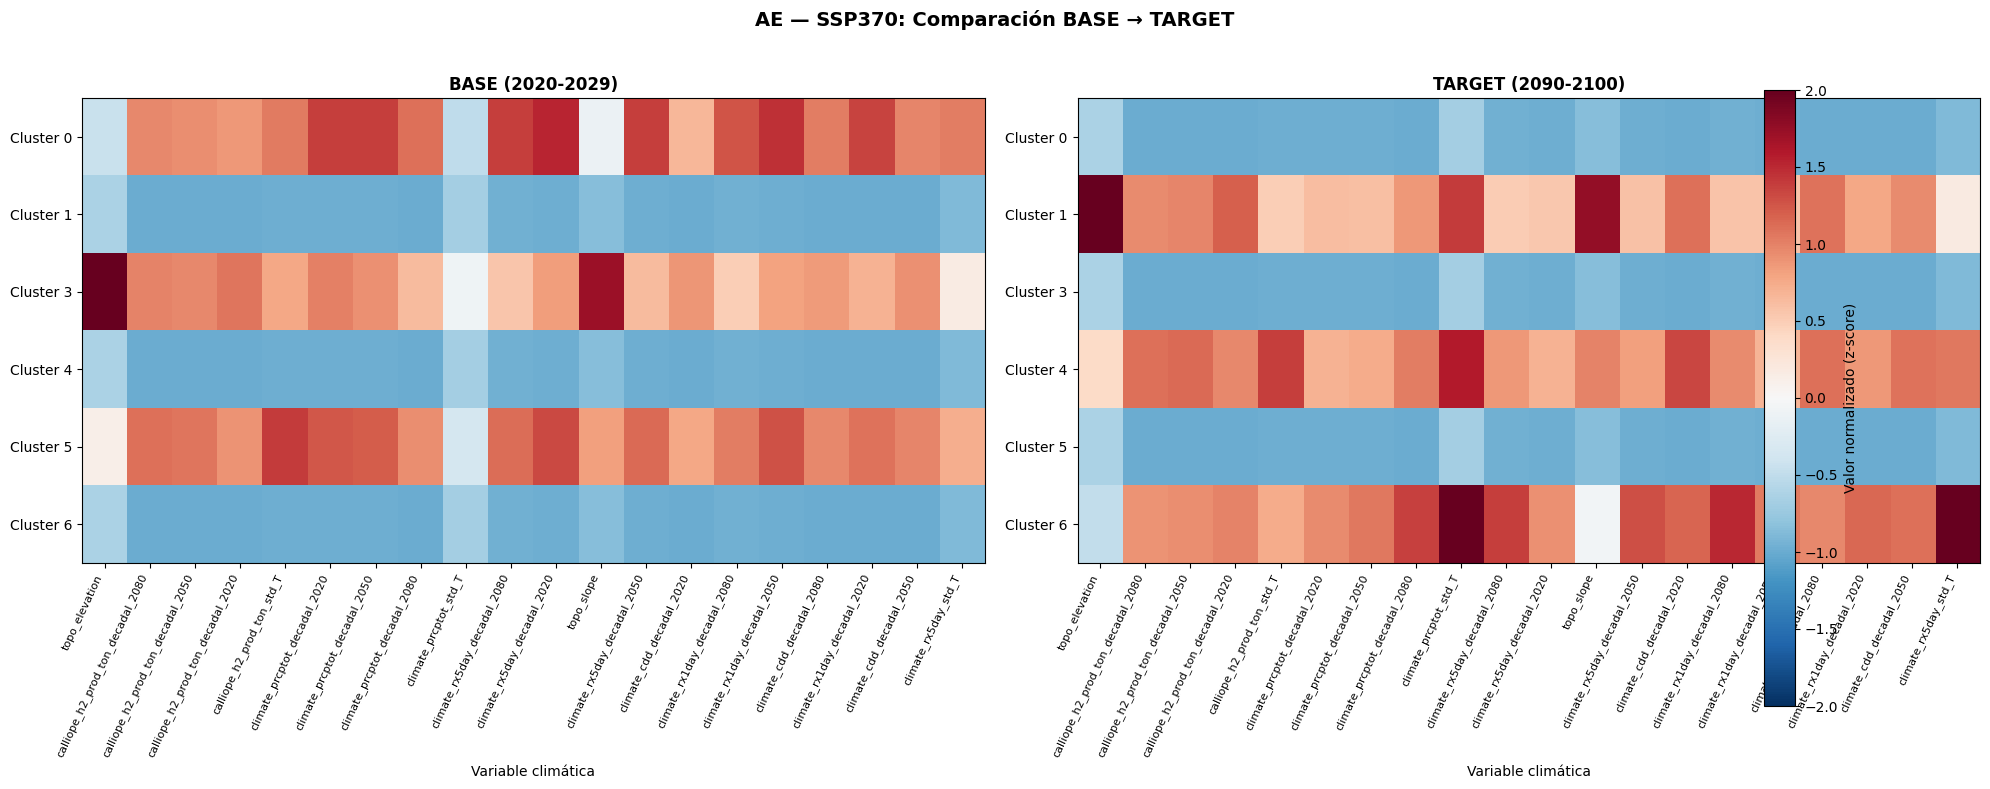


SSP585:


/tmp/ipykernel_65999/3399713422.py:84: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.96])


  Guardado: cluster_comparison_ssp585_ae_k10.png


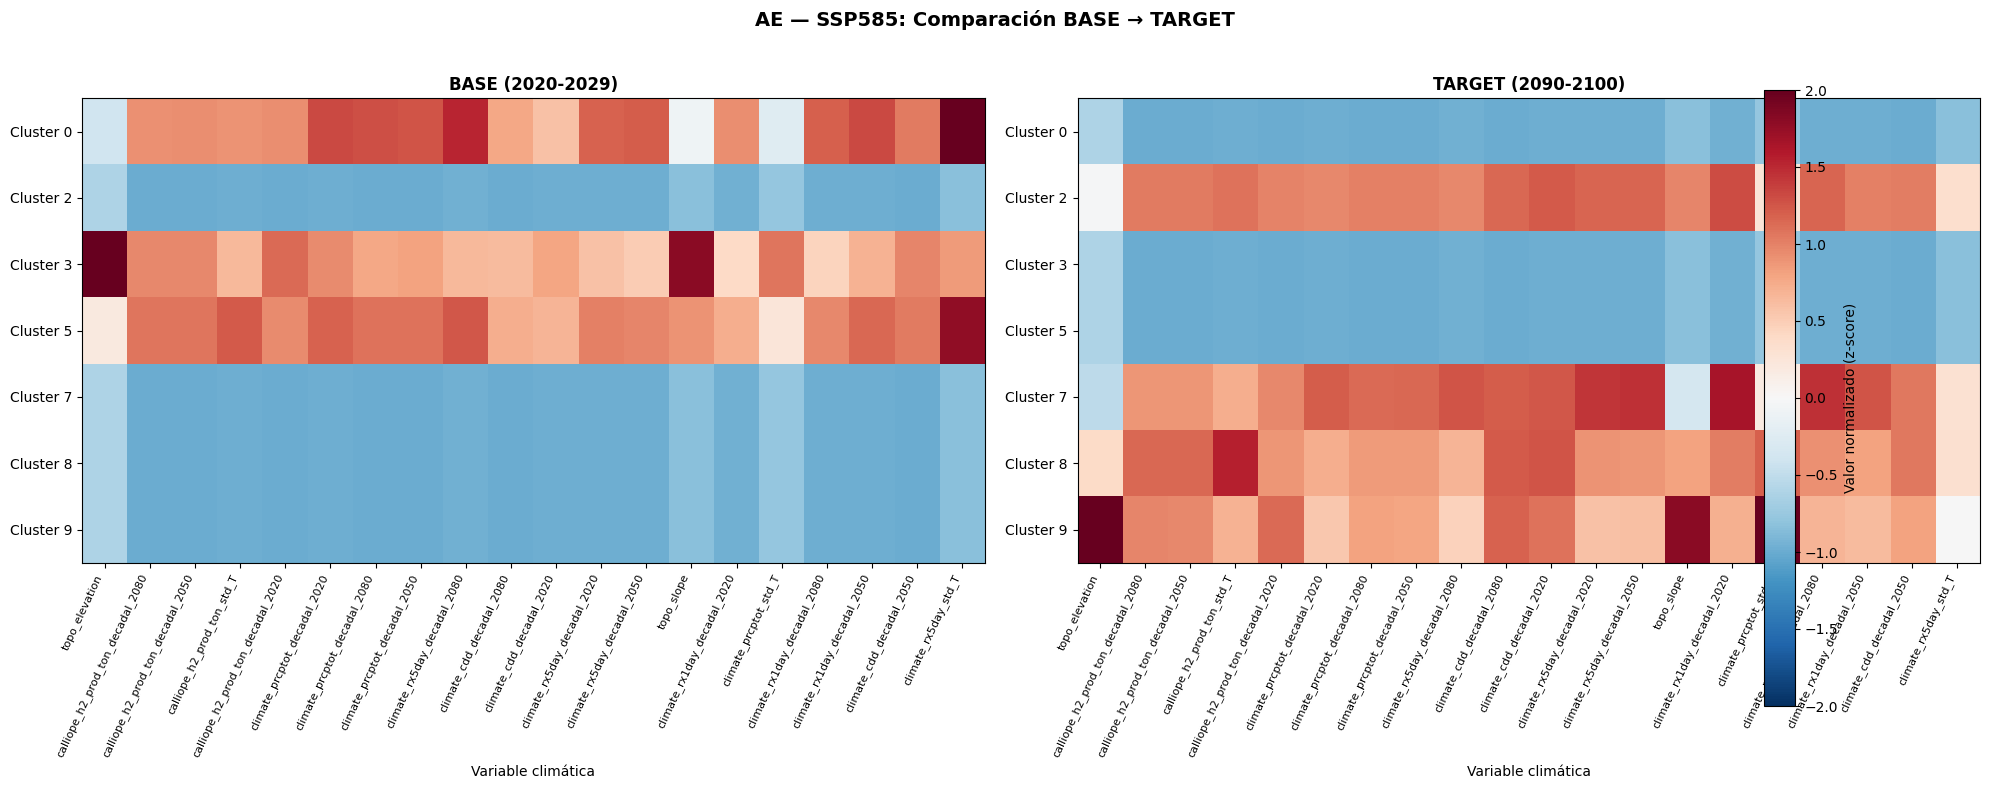


Comparaciones BASE vs TARGET — VAE

SSP245:


/tmp/ipykernel_65999/3399713422.py:84: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.96])


  Guardado: cluster_comparison_ssp245_vae_k10.png


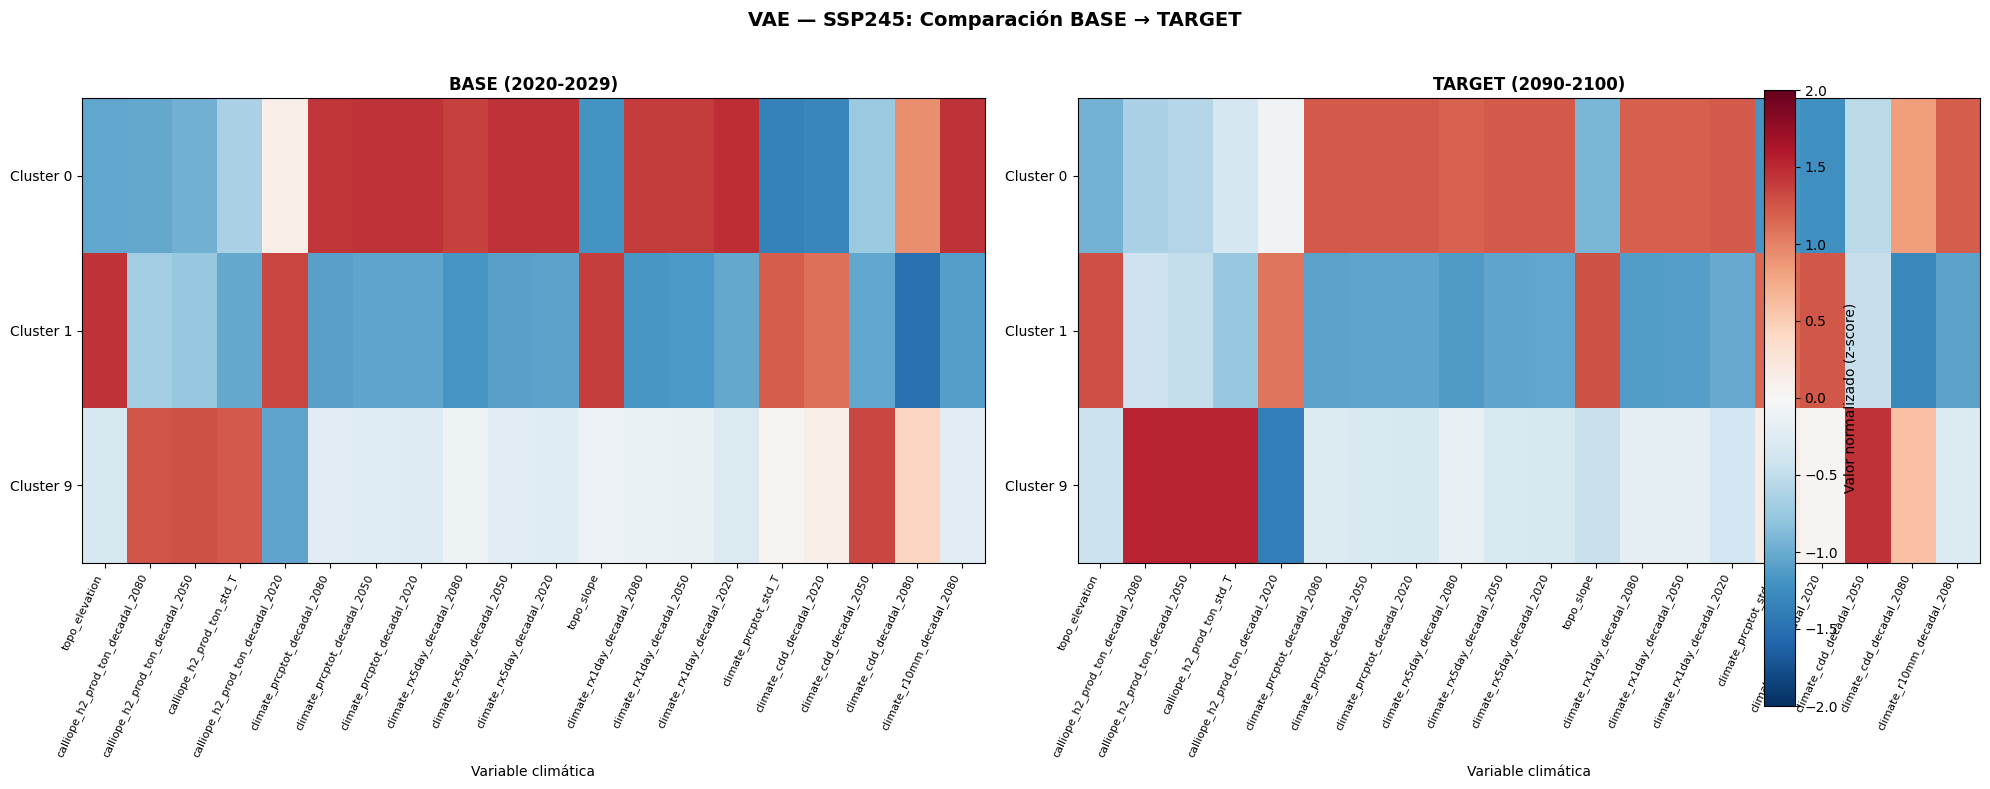


SSP370:


/tmp/ipykernel_65999/3399713422.py:84: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.96])


  Guardado: cluster_comparison_ssp370_vae_k10.png


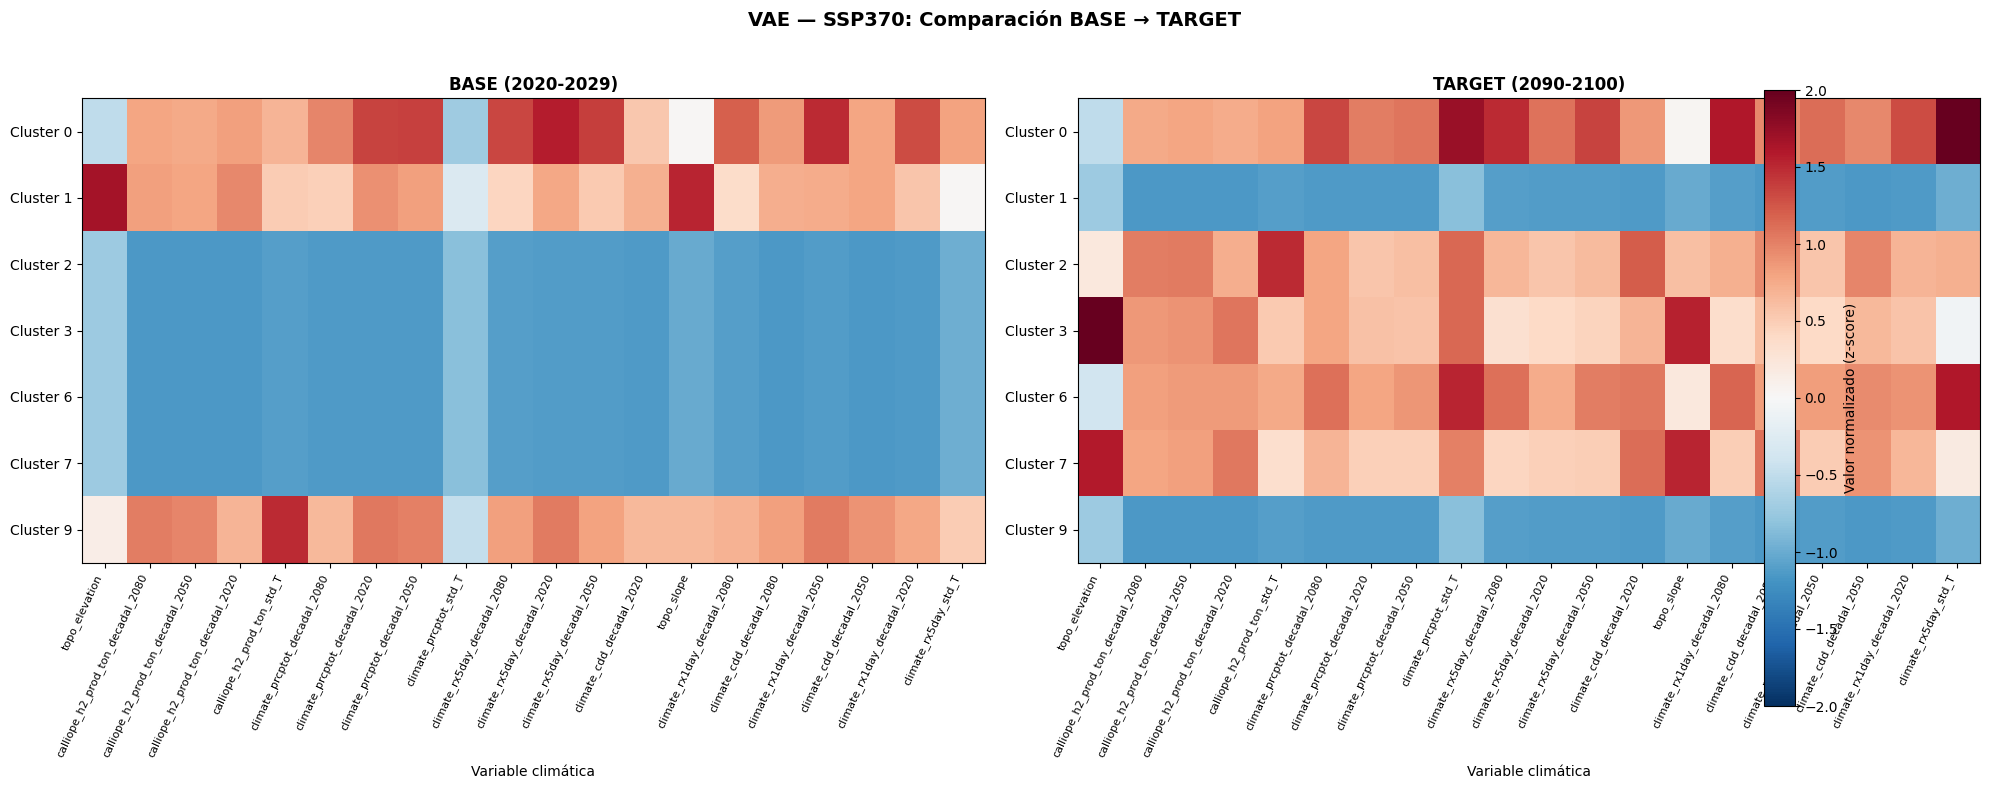


SSP585:


/tmp/ipykernel_65999/3399713422.py:84: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.96])


  Guardado: cluster_comparison_ssp585_vae_k10.png


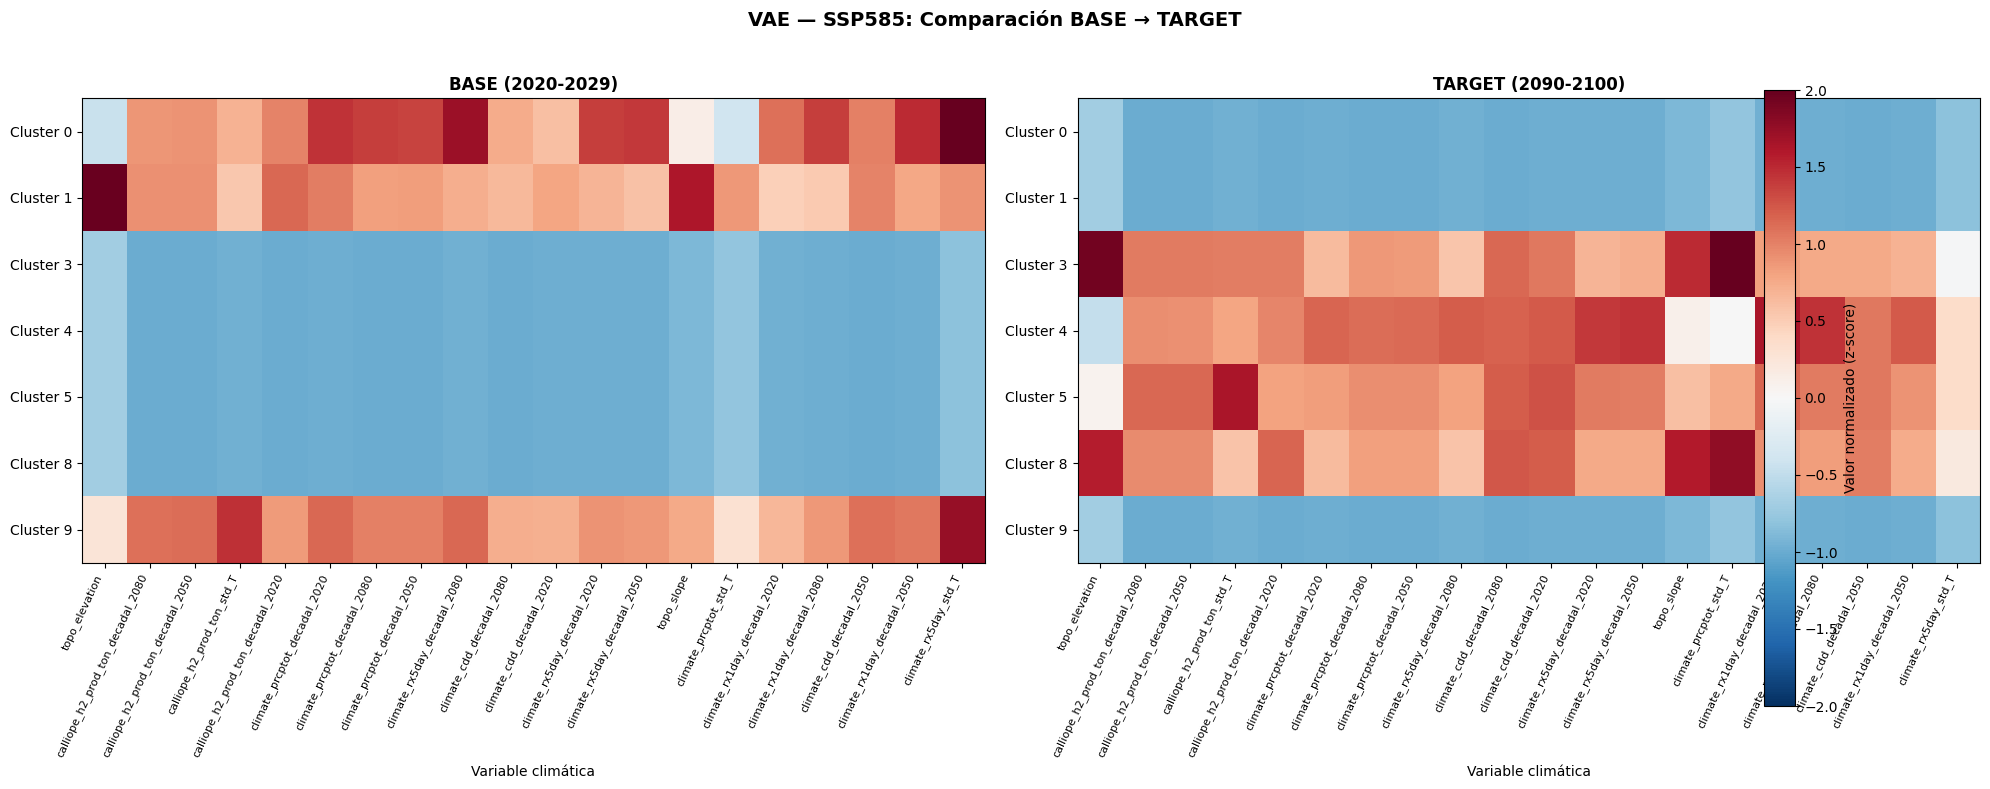

In [47]:
def plot_base_vs_target_comparison(df_base, df_target, model_key, scenario, top_vars=15):
    """
    Visualiza comparación BASE vs TARGET para un escenario específico.
    
    Args:
        df_base: DataFrame con perfiles BASE
        df_target: DataFrame con perfiles TARGET
        model_key: Nombre del modelo (AE/VAE)
        scenario: Nombre del escenario (SSP245/SSP370/SSP585)
        top_vars: Número de variables a mostrar
    """
    
    mean_cols = [col for col in df_base.columns if col.endswith("_mean")]
    
    if not mean_cols:
        print(f"  ERROR: No hay columnas _mean disponibles")
        return
    
    # Calcular varianza para seleccionar top variables
    var_variance = {}
    for col in mean_cols:
        combined_std = pd.concat([df_base[col], df_target[col]]).std()
        var_variance[col] = combined_std
    
    top_mean_cols = sorted(var_variance, key=var_variance.get, reverse=True)[:top_vars]
    top_var_names = [col.replace("_mean", "") for col in top_mean_cols]
    
    # Preparar datos
    cluster_ids_base = df_base["cluster_id"].values
    cluster_ids_target = df_target["cluster_id"].values
    
    # Todos los cluster IDs presentes
    all_cluster_ids = sorted(set(cluster_ids_base) | set(cluster_ids_target))
    
    # Matrices de datos
    data_base = np.zeros((len(all_cluster_ids), len(top_mean_cols)))
    data_target = np.zeros((len(all_cluster_ids), len(top_mean_cols)))
    
    for i, cid in enumerate(all_cluster_ids):
        if cid in cluster_ids_base:
            idx_base = list(cluster_ids_base).index(cid)
            data_base[i, :] = df_base.iloc[idx_base][top_mean_cols].values
        if cid in cluster_ids_target:
            idx_target = list(cluster_ids_target).index(cid)
            data_target[i, :] = df_target.iloc[idx_target][top_mean_cols].values
    
    # Normalizar
    scaler = StandardScaler()
    combined_data = np.vstack([data_base, data_target])
    combined_normalized = scaler.fit_transform(combined_data)
    
    data_base_norm = combined_normalized[:len(all_cluster_ids), :]
    data_target_norm = combined_normalized[len(all_cluster_ids):, :]
    
    # Crear figura con 2 subplots lado a lado
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    
    # BASE (izquierda)
    ax = axes[0]
    im1 = ax.imshow(data_base_norm, cmap="RdBu_r", aspect="auto", vmin=-2, vmax=2)
    ax.set_xticks(range(len(top_var_names)))
    ax.set_xticklabels(top_var_names, rotation=65, ha="right", fontsize=8)
    ax.set_yticks(range(len(all_cluster_ids)))
    ax.set_yticklabels([f"Cluster {cid}" for cid in all_cluster_ids], fontsize=10)
    ax.set_title(f"BASE (2020-2029)", fontsize=12, fontweight="bold")
    ax.set_xlabel("Variable climática", fontsize=10)
    
    # TARGET (derecha)
    ax = axes[1]
    im2 = ax.imshow(data_target_norm, cmap="RdBu_r", aspect="auto", vmin=-2, vmax=2)
    ax.set_xticks(range(len(top_var_names)))
    ax.set_xticklabels(top_var_names, rotation=65, ha="right", fontsize=8)
    ax.set_yticks(range(len(all_cluster_ids)))
    ax.set_yticklabels([f"Cluster {cid}" for cid in all_cluster_ids], fontsize=10)
    ax.set_title(f"TARGET (2090-2100)", fontsize=12, fontweight="bold")
    ax.set_xlabel("Variable climática", fontsize=10)
    
    # Colorbar compartido
    fig.colorbar(im2, ax=axes, fraction=0.02, pad=0.02, label="Valor normalizado (z-score)")
    
    fig.suptitle(f"{model_key} — {scenario}: Comparación BASE → TARGET", 
                 fontsize=14, fontweight="bold", y=0.98)
    
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    
    filename = f"cluster_comparison_{scenario.lower()}_{model_key.lower()}_k{K_CLUSTERS}.png"
    plt.savefig(os.path.join(PLOTS_DIR, filename), dpi=300, bbox_inches="tight")
    print(f"  Guardado: {filename}")
    
    plt.show()


# Generar comparaciones para cada modelo y escenario
for model_key in MODEL_ORDER:
    print(f"\n{'='*60}")
    print(f"Comparaciones BASE vs TARGET — {model_key}")
    print(f"{'='*60}")
    
    df_base = CLUSTER_PROFILES[model_key]
    
    for scenario in ["SSP245", "SSP370", "SSP585"]:
        print(f"\n{scenario}:")
        df_target = CLUSTER_PROFILES_TARGET[scenario][model_key]
        plot_base_vs_target_comparison(df_base, df_target, model_key, scenario, top_vars=20)

## Análisis Comparativo: Todos los Escenarios

Generación de tablas de resiliencia para SSP245, SSP370 y SSP585 en ambos modelos (AE y VAE).

In [48]:
# Generar tablas para todos los modelos y escenarios
RESILIENCE_TABLES = {}

for model_key in MODEL_ORDER:
    RESILIENCE_TABLES[model_key] = {}
    
    print(f"\n{'='*120}")
    print(f"GENERANDO TABLAS DE RESILIENCIA - {model_key}")
    print(f"{'='*120}")
    
    for scenario in ["SSP245", "SSP370", "SSP585"]:
        print(f"\n{scenario}:")
        
        df_res = cluster_resilience_summary(
            model_key=model_key,
            scenario=scenario,
            CLUSTERING_RESULTS=CLUSTERING_RESULTS,
            LATENTS=LATENTS,
            CLUSTER_PROFILES=CLUSTER_PROFILES,
            CLUSTER_PROFILES_TARGET=CLUSTER_PROFILES_TARGET,
            K_CLUSTERS=K_CLUSTERS,
            N_PER_SCENARIO=N_PER_SCENARIO,
            feature_names=feature_names
        )
        
        RESILIENCE_TABLES[model_key][scenario] = df_res
        
        # Resumen por categoría
        resilience_counts = df_res["resilience_category"].value_counts()
        for category in ["Alta", "Media", "Baja"]:
            if category in resilience_counts.index:
                count = resilience_counts[category]
                pct = count / len(df_res) * 100
                print(f"  {category}: {count} clusters ({pct:.1f}%)")

print("\n✓ Tablas de resiliencia generadas para todos los modelos y escenarios")

# Comparación de resiliencia promedio por escenario
print("\n" + "="*120)
print("COMPARACIÓN DE RESILIENCIA PROMEDIO POR ESCENARIO")
print("="*120)

comparison_data = []

for model_key in MODEL_ORDER:
    for scenario in ["SSP245", "SSP370", "SSP585"]:
        df_res = RESILIENCE_TABLES[model_key][scenario]
        
        comparison_data.append({
            "Modelo": model_key,
            "Escenario": scenario,
            "Score Medio": df_res["resilience_score"].mean(),
            "Retention Media (%)": df_res["retention_pct"].mean(),
            "Similitud Media": df_res["signature_similarity"].mean(),
            "% Alta Resiliencia": (df_res["resilience_category"] == "Alta").sum() / len(df_res) * 100,
            "% Baja Resiliencia": (df_res["resilience_category"] == "Baja").sum() / len(df_res) * 100
        })

df_comparison = pd.DataFrame(comparison_data)
print("\n" + df_comparison.to_string(index=False))

print("\n" + "="*120)
print("INTERPRETACIÓN")
print("="*120)
print("""
Score de Resiliencia (0-100):
  - 70-100: Alta resiliencia - El cluster mantiene identidad espacial y climática
  - 40-69:  Media resiliencia - Cambios moderados en distribución o perfil
  - 0-39:   Baja resiliencia - Transformación significativa del cluster

Retention (%): Porcentaje de píxeles del cluster BASE que permanecen en el mismo cluster TARGET

Similitud de Firma: Cosine similarity entre perfiles climáticos BASE y TARGET (0-1)

Variables Dominantes: Top 3 variables con mayor z-score (desviación del promedio global)
  - Valores positivos (+): Por encima del promedio regional
  - Valores negativos (-): Por debajo del promedio regional
""")


GENERANDO TABLAS DE RESILIENCIA - AE

SSP245:
  Alta: 2 clusters (20.0%)
  Media: 1 clusters (10.0%)
  Baja: 7 clusters (70.0%)

SSP370:
  Media: 3 clusters (30.0%)
  Baja: 7 clusters (70.0%)

SSP585:
  Media: 2 clusters (20.0%)
  Baja: 8 clusters (80.0%)

GENERANDO TABLAS DE RESILIENCIA - VAE

SSP245:
  Alta: 2 clusters (20.0%)
  Media: 1 clusters (10.0%)
  Baja: 7 clusters (70.0%)

SSP370:
  Media: 3 clusters (30.0%)
  Baja: 7 clusters (70.0%)

SSP585:
  Media: 3 clusters (30.0%)
  Baja: 7 clusters (70.0%)

✓ Tablas de resiliencia generadas para todos los modelos y escenarios

COMPARACIÓN DE RESILIENCIA PROMEDIO POR ESCENARIO

Modelo Escenario  Score Medio  Retention Media (%)  Similitud Media  % Alta Resiliencia  % Baja Resiliencia
    AE    SSP245    23.521103            24.811898         0.677371                20.0                70.0
    AE    SSP370    14.803560            22.611557         0.639882                 0.0                70.0
    AE    SSP585    13.678480         

## Estabilidad Física: Clasificadores BASE → TARGET

Entrena modelos de clasificación en BASE para predecir clusters desde variables climáticas, luego evalúa si mantienen poder predictivo en TARGET. Esto indica si los clusters conservan su significado físico.

In [49]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score

def train_cluster_classifier(X_train, y_train, feature_names, n_estimators=100, random_state=42):
    """
    Entrena un clasificador Random Forest para predecir clusters desde variables climáticas.
    
    Args:
        X_train: Features climáticas (n_samples, n_features)
        y_train: Labels de clusters (n_samples,)
        feature_names: Nombres de las features
        n_estimators: Número de árboles en el bosque
        random_state: Semilla para reproducibilidad
        
    Returns:
        tuple: (modelo entrenado, importancia de features como DataFrame)
    """
    
    # Entrenar Random Forest
    clf = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=10,
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=random_state,
        n_jobs=-1
    )
    
    clf.fit(X_train, y_train)
    
    # Extraer importancia de features
    feature_importance = pd.DataFrame({
        'feature': feature_names,
        'importance': clf.feature_importances_
    }).sort_values('importance', ascending=False)
    
    return clf, feature_importance


def evaluate_classifier_stability(clf, X_base, y_base, X_target, y_target, 
                                   feature_names, model_key, scenario):
    """
    Evalúa estabilidad del clasificador comparando desempeño en BASE vs TARGET.
    
    Si el accuracy en TARGET es similar al de BASE, significa que las mismas
    variables climáticas siguen definiendo los clusters → estabilidad física.
    
    Args:
        clf: Clasificador entrenado
        X_base: Features BASE
        y_base: Labels BASE
        X_target: Features TARGET
        y_target: Labels TARGET (del clustering original)
        feature_names: Nombres de features
        model_key: Nombre del modelo (AE/VAE)
        scenario: Escenario SSP
        
    Returns:
        dict: Métricas de estabilidad
    """
    
    # Predicción en BASE (train set)
    y_pred_base = clf.predict(X_base)
    acc_base = accuracy_score(y_base, y_pred_base)
    
    # Predicción en TARGET (test temporal)
    y_pred_target = clf.predict(X_target)
    acc_target = accuracy_score(y_target, y_pred_target)
    
    # Cross-validation en BASE (para referencia)
    cv_scores = cross_val_score(clf, X_base, y_base, cv=5, n_jobs=-1)
    cv_mean = cv_scores.mean()
    cv_std = cv_scores.std()
    
    # Delta de accuracy (caída de desempeño)
    acc_drop = acc_base - acc_target
    acc_drop_pct = (acc_drop / acc_base) * 100
    
    # Interpretación de estabilidad física
    if acc_drop_pct < 10:
        stability_interpretation = "Alta estabilidad física"
        stability_note = "Las variables climáticas mantienen su poder predictivo"
    elif acc_drop_pct < 25:
        stability_interpretation = "Estabilidad moderada"
        stability_note = "Ligera degradación en poder predictivo"
    else:
        stability_interpretation = "Baja estabilidad física"
        stability_note = "Las variables climáticas pierden poder predictivo"
    
    return {
        'model': model_key,
        'scenario': scenario,
        'acc_base': acc_base,
        'acc_target': acc_target,
        'acc_drop': acc_drop,
        'acc_drop_pct': acc_drop_pct,
        'cv_mean': cv_mean,
        'cv_std': cv_std,
        'stability': stability_interpretation,
        'note': stability_note
    }


def analyze_feature_importance_shift(importance_base, clf_target, X_target, y_target, feature_names):
    """
    Compara importancia de features entre BASE y TARGET para detectar cambios
    en las variables que definen los clusters.
    
    Args:
        importance_base: DataFrame con importancia en BASE
        clf_target: Clasificador re-entrenado en TARGET
        X_target: Features TARGET
        y_target: Labels TARGET
        feature_names: Nombres de features
        
    Returns:
        pd.DataFrame: Tabla comparativa de importancias
    """
    
    # Re-entrenar en TARGET para comparar importancias
    clf_target.fit(X_target, y_target)
    
    importance_target = pd.DataFrame({
        'feature': feature_names,
        'importance_target': clf_target.feature_importances_
    })
    
    # Merge con BASE
    comparison = importance_base.merge(
        importance_target, 
        on='feature', 
        suffixes=('_base', '_target')
    )
    
    # Cambio en importancia
    comparison['importance_change'] = (
        comparison['importance_target'] - comparison['importance']
    )
    comparison['importance_change_pct'] = (
        (comparison['importance_change'] / comparison['importance']) * 100
    )
    
    # Ordenar por importancia BASE
    comparison = comparison.sort_values('importance', ascending=False)
    
    return comparison


# Análisis completo para AE SSP245
print("Análisis de Estabilidad Física - Clasificadores BASE → TARGET")
print("\nEjemplo: AE SSP245")

model_key = "AE"
results = CLUSTERING_RESULTS[model_key]

# Datos BASE
labels_base = results["labels_base"][:N_PER_SCENARIO]
X_base_data = X245_orig  # Usar todas las variables climáticas

# Datos TARGET SSP245
labels_T245 = results["labels_T245"]
X_T245_data = X245_orig  # Mismo dataset, diferentes labels de cluster

print(f"\nDatos:")
print(f"  X_BASE: {X_base_data.shape}")
print(f"  X_TARGET: {X_T245_data.shape}")
print(f"  Features: {len(feature_names)}")
print(f"  Clusters: {K_CLUSTERS}")

# 1. Entrenar clasificador en BASE
print("\n1. Entrenando clasificador en BASE...")
clf_base, importance_base = train_cluster_classifier(
    X_base_data, labels_base, feature_names
)

print(f"\nTop 10 variables más importantes en BASE:")
print(importance_base.head(10).to_string(index=False))

# 2. Evaluar en TARGET
print("\n2. Evaluando en TARGET...")
stability_metrics = evaluate_classifier_stability(
    clf_base, X_base_data, labels_base, 
    X_T245_data, labels_T245, 
    feature_names, model_key, "SSP245"
)

print(f"\nMétricas de estabilidad:")
print(f"  Accuracy BASE: {stability_metrics['acc_base']:.4f}")
print(f"  Accuracy TARGET: {stability_metrics['acc_target']:.4f}")
print(f"  CV BASE (mean ± std): {stability_metrics['cv_mean']:.4f} ± {stability_metrics['cv_std']:.4f}")
print(f"  Caída de accuracy: {stability_metrics['acc_drop']:.4f} ({stability_metrics['acc_drop_pct']:.1f}%)")
print(f"\n  → {stability_metrics['stability']}")
print(f"  → {stability_metrics['note']}")

# 3. Analizar cambio en importancia de features
print("\n3. Comparando importancia de features BASE vs TARGET...")
clf_target = RandomForestClassifier(
    n_estimators=100, max_depth=10, min_samples_split=10, 
    min_samples_leaf=5, random_state=42, n_jobs=-1
)

importance_comparison = analyze_feature_importance_shift(
    importance_base, clf_target, X_T245_data, labels_T245, feature_names
)

print(f"\nTop 10 variables con mayor cambio en importancia:")
print(importance_comparison.nlargest(10, 'importance_change_pct')[
    ['feature', 'importance', 'importance_target', 'importance_change_pct']
].to_string(index=False))

print("\n✓ Análisis de estabilidad física completado")

Análisis de Estabilidad Física - Clasificadores BASE → TARGET

Ejemplo: AE SSP245

Datos:
  X_BASE: (661, 47)
  X_TARGET: (661, 47)
  Features: 47
  Clusters: 10

1. Entrenando clasificador en BASE...

Top 10 variables más importantes en BASE:
                         feature  importance
                  topo_elevation    0.085333
climate_rx5day_decadal_mean_2080    0.063170
            climate_rx5day_std_T    0.058922
climate_rx5day_decadal_mean_2020    0.056693
            climate_rx1day_std_T    0.051906
climate_rx5day_decadal_mean_2050    0.049140
              climate_sdii_std_T    0.048468
climate_rx1day_decadal_mean_2050    0.044560
climate_rx1day_decadal_mean_2080    0.035901
  climate_sdii_decadal_mean_2080    0.035391

2. Evaluando en TARGET...

Top 10 variables más importantes en BASE:
                         feature  importance
                  topo_elevation    0.085333
climate_rx5day_decadal_mean_2080    0.063170
            climate_rx5day_std_T    0.058922
climate_rx5

In [50]:
# Análisis completo para todos los modelos y escenarios
print("\n" + "="*120)
print("ANÁLISIS DE ESTABILIDAD FÍSICA - TODOS LOS ESCENARIOS")
print("="*120)

CLASSIFIER_RESULTS = {}
FEATURE_IMPORTANCE_COMPARISONS = {}

for model_key in MODEL_ORDER:
    CLASSIFIER_RESULTS[model_key] = {}
    FEATURE_IMPORTANCE_COMPARISONS[model_key] = {}
    
    print(f"\n{'='*80}")
    print(f"Modelo: {model_key}")
    print(f"{'='*80}")
    
    results = CLUSTERING_RESULTS[model_key]
    labels_base = results["labels_base"][:N_PER_SCENARIO]
    
    # Entrenar una vez en BASE (reutilizar para todos los escenarios)
    print(f"\nEntrenando clasificador BASE...")
    clf_base, importance_base = train_cluster_classifier(
        X245_orig, labels_base, feature_names
    )
    
    print(f"\nTop 5 variables más importantes en BASE:")
    print(importance_base.head(5).to_string(index=False))
    
    # Evaluar en cada escenario TARGET
    for scenario, X_target_data, labels_key in [
        ("SSP245", X245_orig, "labels_T245"),
        ("SSP370", X370_orig, "labels_T370"),
        ("SSP585", X585_orig, "labels_T585")
    ]:
        print(f"\n{scenario}:")
        
        labels_target = results[labels_key]
        
        # Evaluar estabilidad
        stability = evaluate_classifier_stability(
            clf_base, X245_orig, labels_base,
            X_target_data, labels_target,
            feature_names, model_key, scenario
        )
        
        CLASSIFIER_RESULTS[model_key][scenario] = stability
        
        print(f"  Accuracy BASE: {stability['acc_base']:.4f}")
        print(f"  Accuracy TARGET: {stability['acc_target']:.4f}")
        print(f"  Caída: {stability['acc_drop_pct']:.1f}%")
        print(f"  → {stability['stability']}")
        
        # Comparar importancia de features
        clf_temp = RandomForestClassifier(
            n_estimators=100, max_depth=10, min_samples_split=10,
            min_samples_leaf=5, random_state=42, n_jobs=-1
        )
        
        importance_comp = analyze_feature_importance_shift(
            importance_base, clf_temp, X_target_data, labels_target, feature_names
        )
        
        FEATURE_IMPORTANCE_COMPARISONS[model_key][scenario] = importance_comp

print("\n" + "="*120)
print("RESUMEN DE ESTABILIDAD FÍSICA")
print("="*120)

# Crear tabla resumen
stability_summary = []

for model_key in MODEL_ORDER:
    for scenario in ["SSP245", "SSP370", "SSP585"]:
        metrics = CLASSIFIER_RESULTS[model_key][scenario]
        stability_summary.append({
            "Modelo": metrics['model'],
            "Escenario": metrics['scenario'],
            "Acc BASE": metrics['acc_base'],
            "Acc TARGET": metrics['acc_target'],
            "Caída %": metrics['acc_drop_pct'],
            "CV BASE": metrics['cv_mean'],
            "Estabilidad": metrics['stability']
        })

df_stability = pd.DataFrame(stability_summary)
print("\n" + df_stability.to_string(index=False))

print("\n" + "="*120)
print("INTERPRETACIÓN")
print("="*120)
print("""
Accuracy BASE: Qué tan bien el clasificador predice clusters en el período de entrenamiento
Accuracy TARGET: Qué tan bien predice clusters en el futuro usando las MISMAS variables

Caída de Accuracy:
  - < 10%: Alta estabilidad física → Las variables climáticas mantienen su significado
  - 10-25%: Estabilidad moderada → Cambios graduales en definición de clusters
  - > 25%: Baja estabilidad → Los clusters pierden su identidad física original

Si Accuracy TARGET es alta:
  → Los clusters conservan su significado físico
  → Las mismas variables siguen determinando la membresía
  → Continuidad conceptual entre BASE y TARGET

Si Accuracy TARGET es baja:
  → Los clusters cambian fundamentalmente
  → Nuevas dinámicas climáticas emergen
  → Discontinuidad física en la definición de clusters
""")


ANÁLISIS DE ESTABILIDAD FÍSICA - TODOS LOS ESCENARIOS

Modelo: AE

Entrenando clasificador BASE...

Top 5 variables más importantes en BASE:
                         feature  importance
                  topo_elevation    0.085333
climate_rx5day_decadal_mean_2080    0.063170
            climate_rx5day_std_T    0.058922
climate_rx5day_decadal_mean_2020    0.056693
            climate_rx1day_std_T    0.051906

SSP245:
  Accuracy BASE: 0.9849
  Accuracy TARGET: 0.8623
  Caída: 12.4%
  → Estabilidad moderada

SSP370:
  Accuracy BASE: 0.9849
  Accuracy TARGET: 0.8623
  Caída: 12.4%
  → Estabilidad moderada

SSP370:
  Accuracy BASE: 0.9849
  Accuracy TARGET: 0.0000
  Caída: 100.0%
  → Baja estabilidad física

SSP585:
  Accuracy BASE: 0.9849
  Accuracy TARGET: 0.0000
  Caída: 100.0%
  → Baja estabilidad física

SSP585:
  Accuracy BASE: 0.9849
  Accuracy TARGET: 0.0000
  Caída: 100.0%
  → Baja estabilidad física

Modelo: VAE

Entrenando clasificador BASE...

Top 5 variables más importantes en


GENERANDO VISUALIZACIONES DE IMPORTANCIA DE FEATURES

AE:
  SSP245...
  Guardado: feature_importance_ssp245_ae_k10.png
  Guardado: feature_importance_ssp245_ae_k10.png


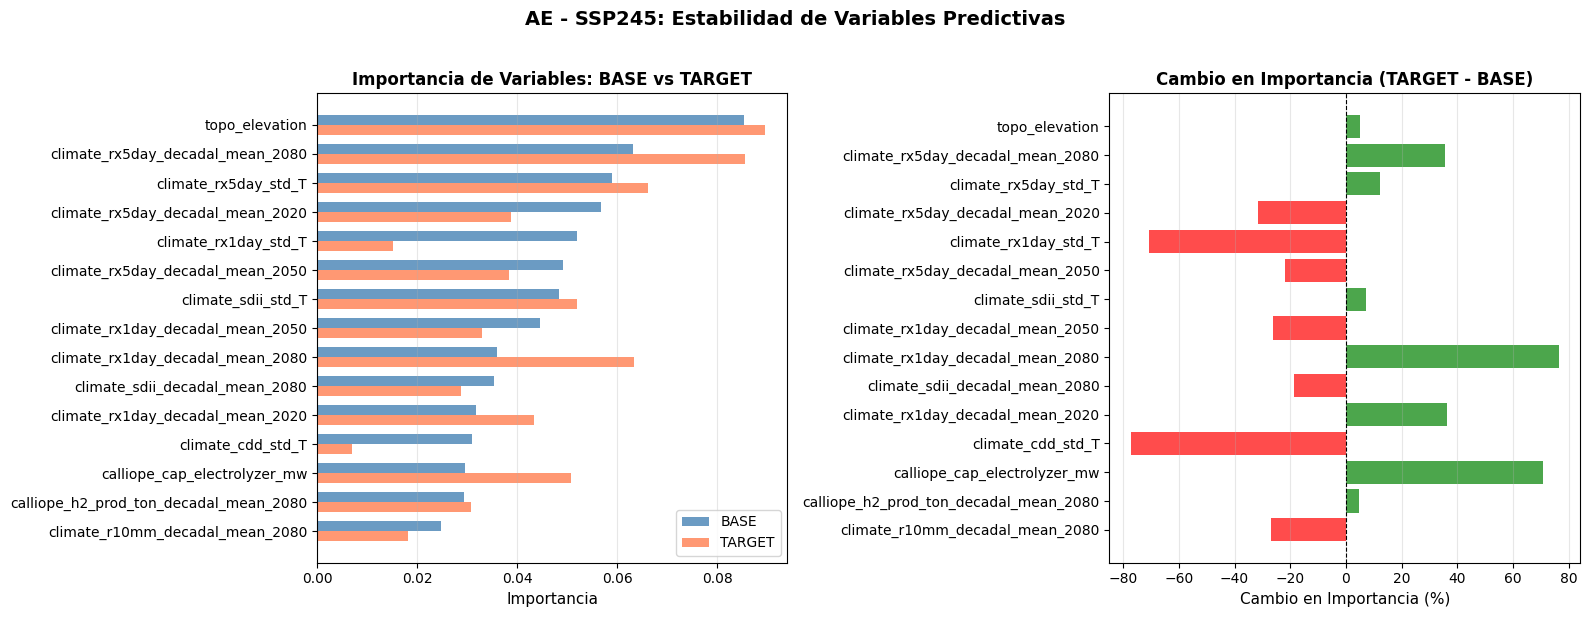

  SSP370...
  Guardado: feature_importance_ssp370_ae_k10.png
  Guardado: feature_importance_ssp370_ae_k10.png


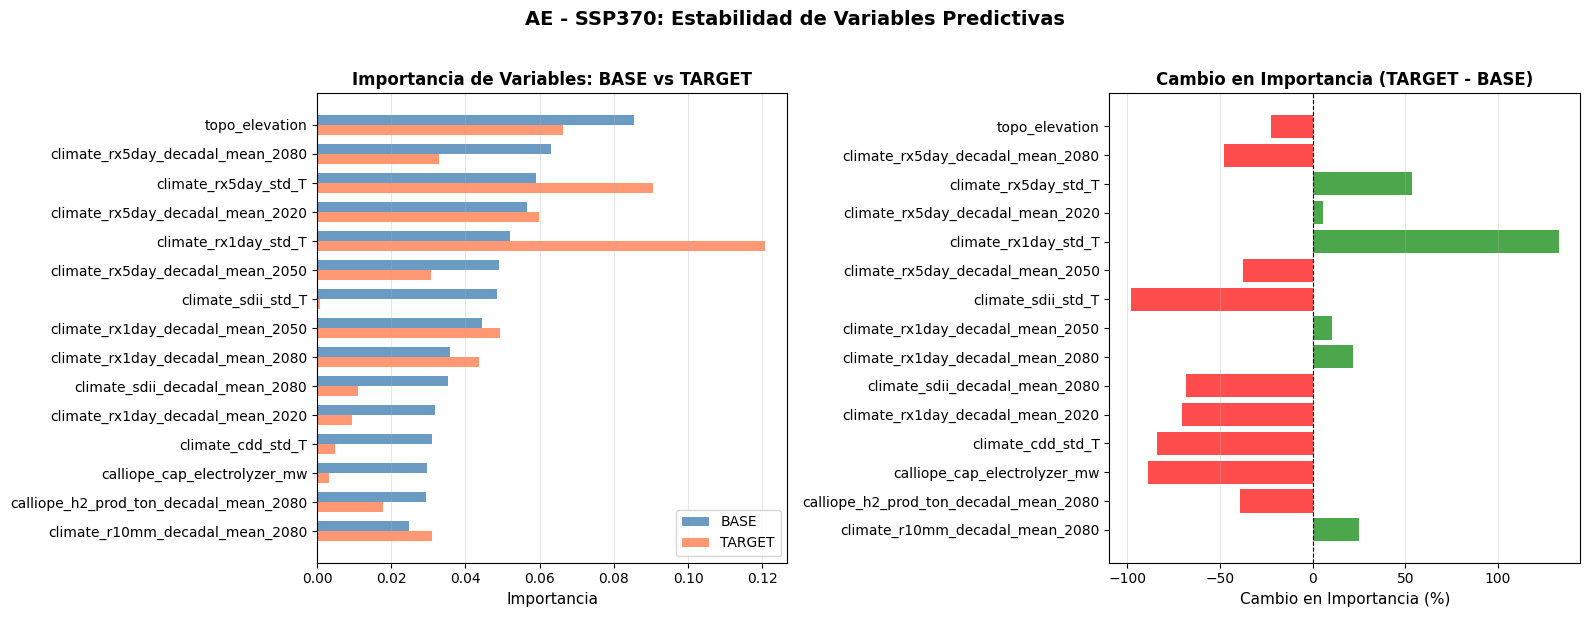

  SSP585...
  Guardado: feature_importance_ssp585_ae_k10.png
  Guardado: feature_importance_ssp585_ae_k10.png


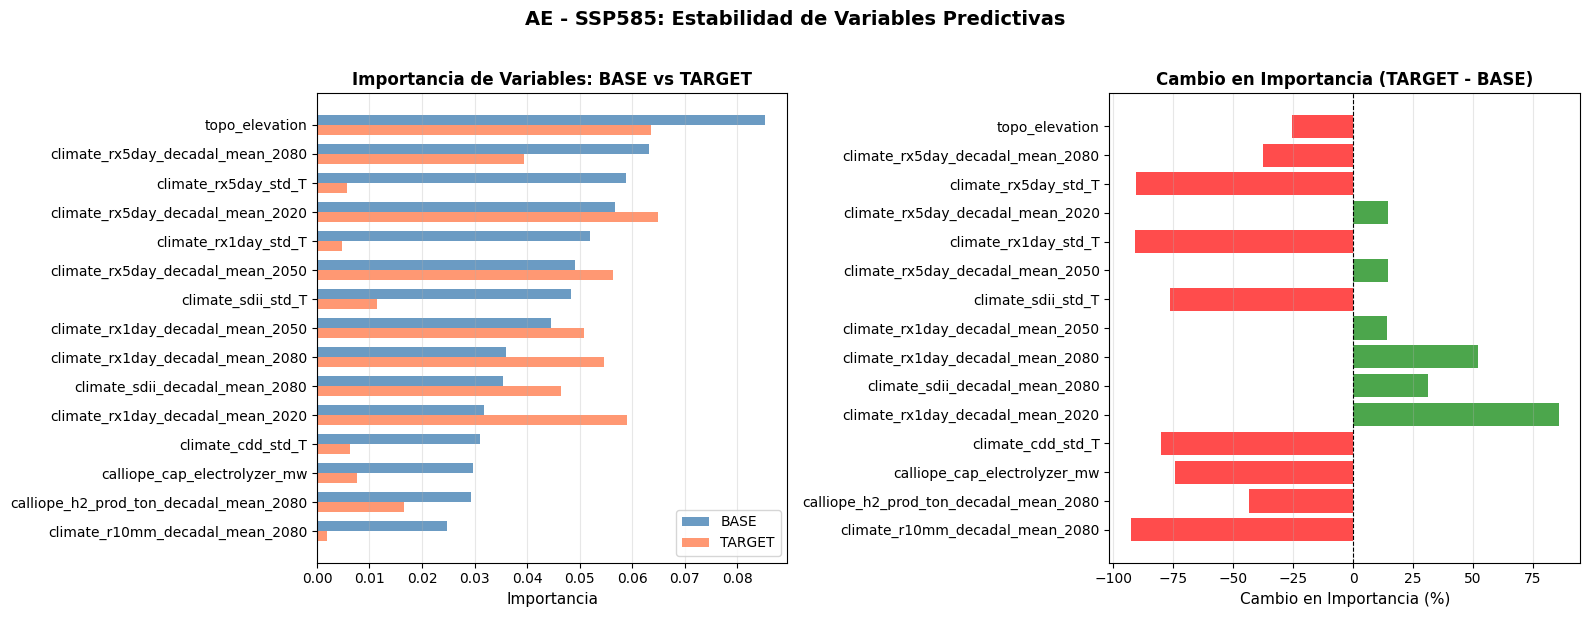


VAE:
  SSP245...
  Guardado: feature_importance_ssp245_vae_k10.png
  Guardado: feature_importance_ssp245_vae_k10.png


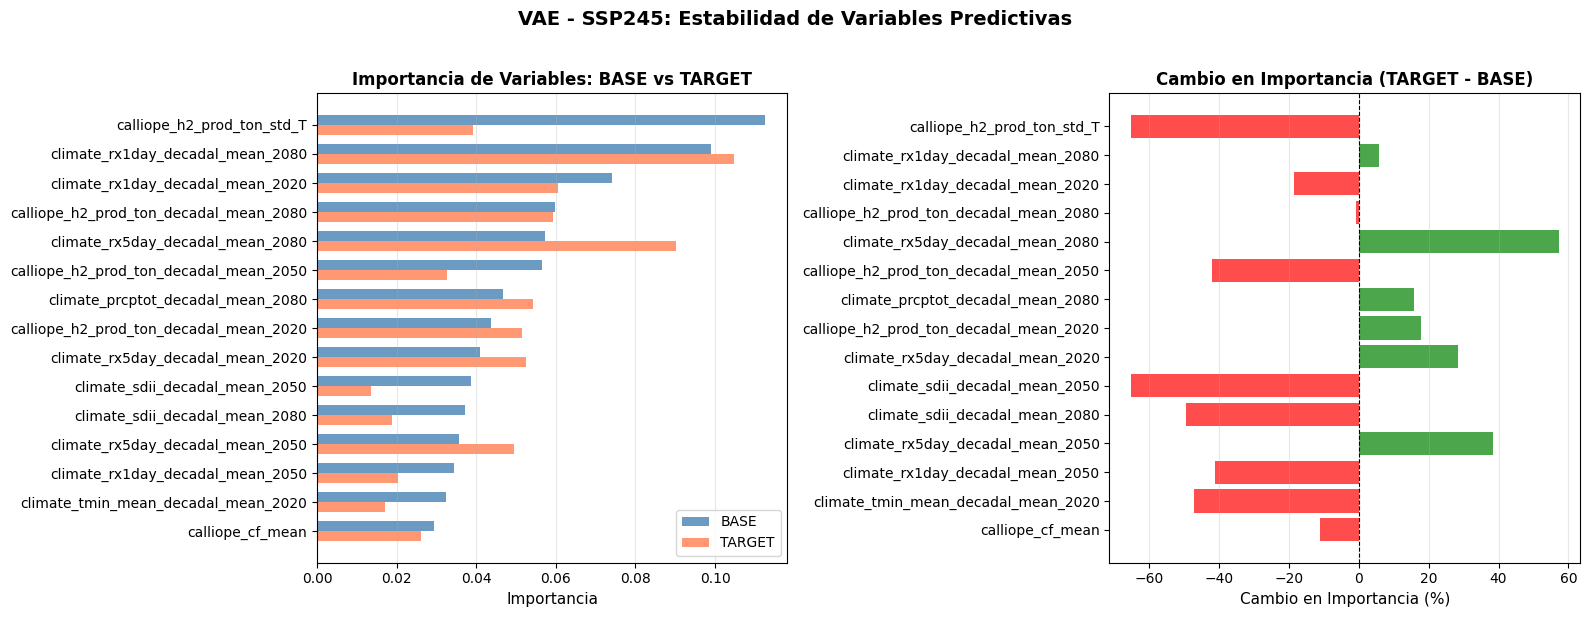

  SSP370...
  Guardado: feature_importance_ssp370_vae_k10.png
  Guardado: feature_importance_ssp370_vae_k10.png


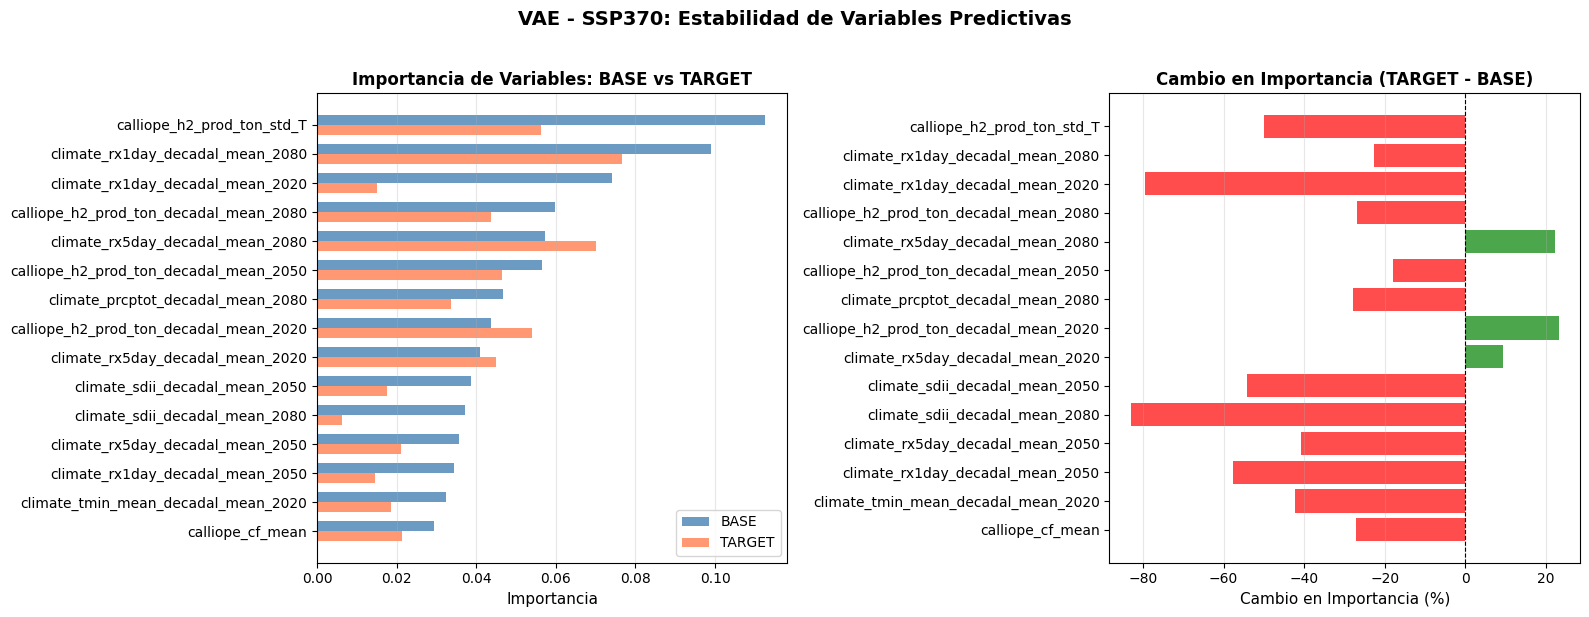

  SSP585...
  Guardado: feature_importance_ssp585_vae_k10.png
  Guardado: feature_importance_ssp585_vae_k10.png


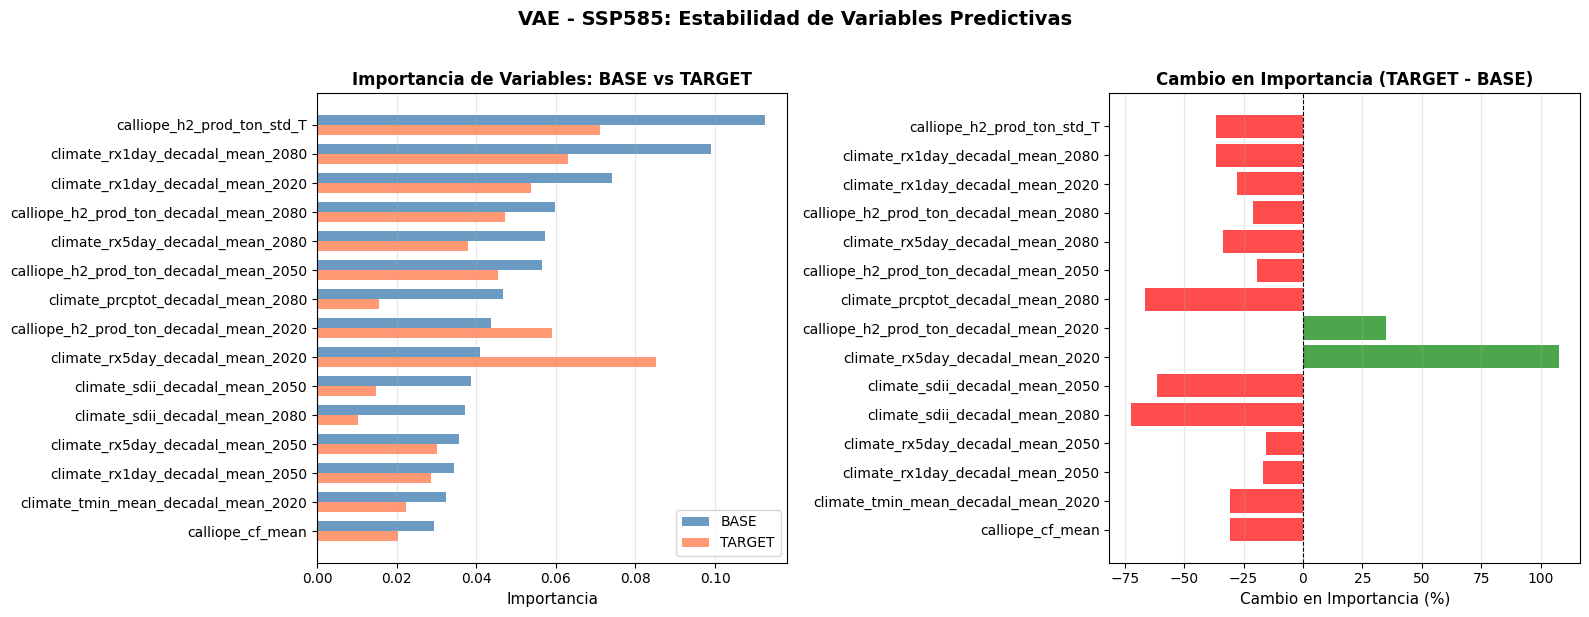


✓ Visualizaciones generadas


In [51]:
# Visualización: Comparación de importancia de features BASE vs TARGET
def plot_feature_importance_comparison(importance_comp, model_key, scenario, top_n=15):
    """
    Visualiza cómo cambia la importancia de features entre BASE y TARGET.
    
    Args:
        importance_comp: DataFrame con comparación de importancias
        model_key: Nombre del modelo
        scenario: Escenario SSP
        top_n: Número de features a mostrar
    """
    
    # Seleccionar top N features por importancia BASE
    top_features = importance_comp.head(top_n)
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Panel 1: Barras comparativas
    ax = axes[0]
    x_pos = np.arange(len(top_features))
    width = 0.35
    
    bars1 = ax.barh(x_pos - width/2, top_features['importance'], 
                     width, label='BASE', color='steelblue', alpha=0.8)
    bars2 = ax.barh(x_pos + width/2, top_features['importance_target'], 
                     width, label='TARGET', color='coral', alpha=0.8)
    
    ax.set_yticks(x_pos)
    ax.set_yticklabels(top_features['feature'])
    ax.invert_yaxis()
    ax.set_xlabel('Importancia', fontsize=11)
    ax.set_title(f'Importancia de Variables: BASE vs TARGET', fontsize=12, fontweight='bold')
    ax.legend(loc='lower right')
    ax.grid(axis='x', alpha=0.3)
    
    # Panel 2: Cambio porcentual
    ax = axes[1]
    colors = ['green' if x > 0 else 'red' for x in top_features['importance_change_pct']]
    
    ax.barh(x_pos, top_features['importance_change_pct'], color=colors, alpha=0.7)
    ax.set_yticks(x_pos)
    ax.set_yticklabels(top_features['feature'])
    ax.invert_yaxis()
    ax.set_xlabel('Cambio en Importancia (%)', fontsize=11)
    ax.set_title(f'Cambio en Importancia (TARGET - BASE)', fontsize=12, fontweight='bold')
    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
    ax.grid(axis='x', alpha=0.3)
    
    fig.suptitle(f'{model_key} - {scenario}: Estabilidad de Variables Predictivas', 
                 fontsize=14, fontweight='bold', y=1.02)
    
    plt.tight_layout()
    
    filename = f"feature_importance_{scenario.lower()}_{model_key.lower()}_k{K_CLUSTERS}.png"
    plt.savefig(os.path.join(PLOTS_DIR, filename), dpi=300, bbox_inches='tight')
    print(f"  Guardado: {filename}")
    
    plt.show()


# Generar visualizaciones para cada modelo y escenario
print("\n" + "="*120)
print("GENERANDO VISUALIZACIONES DE IMPORTANCIA DE FEATURES")
print("="*120)

for model_key in MODEL_ORDER:
    print(f"\n{model_key}:")
    for scenario in ["SSP245", "SSP370", "SSP585"]:
        print(f"  {scenario}...")
        importance_comp = FEATURE_IMPORTANCE_COMPARISONS[model_key][scenario]
        plot_feature_importance_comparison(importance_comp, model_key, scenario, top_n=15)

print("\n✓ Visualizaciones generadas")

## Actualización de Terminología: Resiliencia → Estabilidad/Evolución

Aplicar cambios para usar terminología neutral descriptiva.

In [54]:
# Renombrar el diccionario principal
EVOLUTION_TABLES = RESILIENCE_TABLES

# Actualizar nombres de columnas en todas las tablas
for model_key in MODEL_ORDER:
    for scenario in ["SSP245", "SSP370", "SSP585"]:
        if model_key in EVOLUTION_TABLES and scenario in EVOLUTION_TABLES[model_key]:
            df = EVOLUTION_TABLES[model_key][scenario]
            
            # Renombrar columnas
            if 'resilience_score' in df.columns:
                df.rename(columns={'resilience_score': 'stability_score'}, inplace=True)
            if 'resilience_category' in df.columns:
                df.rename(columns={'resilience_category': 'stability_category'}, inplace=True)

print("✓ Diccionario renombrado: RESILIENCE_TABLES → EVOLUTION_TABLES")
print("✓ Columnas actualizadas: resilience_score → stability_score")
print("✓ Columnas actualizadas: resilience_category → stability_category")

# Mostrar ejemplo
print("\nEjemplo de tabla actualizada (AE SSP245):")
print("\nColumnas disponibles:", list(EVOLUTION_TABLES["AE"]["SSP245"].columns))
print("\nPrimeras filas:")
print(EVOLUTION_TABLES["AE"]["SSP245"][["cluster_base", "stability_category", "stability_score", "retention_pct"]].head())

✓ Diccionario renombrado: RESILIENCE_TABLES → EVOLUTION_TABLES
✓ Columnas actualizadas: resilience_score → stability_score
✓ Columnas actualizadas: resilience_category → stability_category

Ejemplo de tabla actualizada (AE SSP245):

Columnas disponibles: ['cluster_base', 'cluster_target', 'match_quality', 'jaccard', 'retention_pct', 'n_pixels_base', 'n_pixels_target', 'size_change_pct', 'size_evolution', 'signature_similarity', 'signature_status', 'displacement_norm', 'dispersion_change_pct', 'centroid_stability', 'cluster_name', 'defining_variables', 'stability_score', 'stability_category']

Primeras filas:
   cluster_base stability_category  stability_score  retention_pct
0             3               Alta        98.656632     100.000000
1             5               Alta        76.684655      89.677419
2             0              Media        59.869738      58.441558
3             1               Baja         0.000000       0.000000
4             2               Baja         0.0000

## Exportar Tablas de Evolución de Clusters

Guardar tablas en CSV para análisis posterior y reportes.

In [55]:
from datetime import datetime

# Crear directorio para reportes
REPORTS_DIR = os.path.join(BASE_DIR, "reports", "cluster_evolution")
os.makedirs(REPORTS_DIR, exist_ok=True)

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# Exportar tabla individual por modelo y escenario
for model_key in MODEL_ORDER:
    for scenario in ["SSP245", "SSP370", "SSP585"]:
        df_evo = EVOLUTION_TABLES[model_key][scenario]
        
        filename = f"cluster_evolution_{model_key}_{scenario}_k{K_CLUSTERS}_{timestamp}.csv"
        filepath = os.path.join(REPORTS_DIR, filename)
        
        df_evo.to_csv(filepath, index=False, float_format="%.4f")
        print(f"Guardado: {filename}")

# Exportar tabla comparativa
df_comparison.to_csv(
    os.path.join(REPORTS_DIR, f"evolution_comparison_k{K_CLUSTERS}_{timestamp}.csv"),
    index=False,
    float_format="%.4f"
)
print(f"\nGuardado: evolution_comparison_k{K_CLUSTERS}_{timestamp}.csv")

print(f"\n✓ Todas las tablas exportadas a: {REPORTS_DIR}")

Guardado: cluster_evolution_AE_SSP245_k10_20251115_075517.csv
Guardado: cluster_evolution_AE_SSP370_k10_20251115_075517.csv
Guardado: cluster_evolution_AE_SSP585_k10_20251115_075517.csv
Guardado: cluster_evolution_VAE_SSP245_k10_20251115_075517.csv
Guardado: cluster_evolution_VAE_SSP370_k10_20251115_075517.csv
Guardado: cluster_evolution_VAE_SSP585_k10_20251115_075517.csv

Guardado: evolution_comparison_k10_20251115_075517.csv

✓ Todas las tablas exportadas a: /home/aninotna/magister/tesis/justh2_pipeline/reports/cluster_evolution
